# FAO DATALAB

Objectif : produire une analyse détaillée sur les données de la FAO de 2023 sur la sous-nutrition à l'échelle mondiale

## Intro. Initialisation du projet

### **1. Importation des librairies**

In [78]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import country_converter as coco
import scipy.stats as stats
import scipy.stats as spearmanr
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "sans-serif"

### **2. Importation des datasets**

*Import de 5 fichiers CSV de FAOSTAT tous structurés selon le schéma standard FAO : Code Domaine, Domaine, Code zone, Zone, Code Élément, Élément, Code Produit, Produit, Code année, Année, Unité, Valeur, Note*

In [2]:
df_animaux = pd.read_csv(r"C:\Users\maril\Documents\FAO_Datalab\Data\2023\fr_animaux.csv")
df_cereales = pd.read_csv(r"C:\Users\maril\Documents\FAO_Datalab\Data\2023\fr_céréales.csv")
df_population = pd.read_csv(r"C:\Users\maril\Documents\FAO_Datalab\Data\2023\fr_population.csv")
df_vegetaux = pd.read_csv(r"C:\Users\maril\Documents\FAO_Datalab\Data\2023\fr_vegetaux.csv")
df_sousalimentation = pd.read_csv(r"C:\Users\maril\Documents\FAO_Datalab\Data\Périodes_glissantes\fr_sousalimentation.csv")

### **3. Vérification de l'importation - Encodage**

In [3]:
df_animaux.head()
df_cereales.head()
df_population.head()
df_vegetaux.head()
df_sousalimentation.head()

,Code Domaine,Domaine,Code zone (FAO),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FS,Données de la sécurité alimentaire,2,Afghanistan,6121,Valeur,210041,Prévalence de la sous-alimentation (%) (moyenne sur 3 ans),20192021,2019-2021,%,28.9,E,Valeur estimée,NaN
1,FS,Données de la sécurité alimentaire,2,Afghanistan,6121,Valeur,210041,Prévalence de la sous-alimentation (%) (moyenne sur 3 ans),20202022,2020-2022,%,31,E,Valeur estimée,NaN
2,FS,Données de la sécurité alimentaire,2,Afghanistan,6121,Valeur,210041,Prévalence de la sous-alimentation (%) (moyenne sur 3 ans),20212023,2021-2023,%,32,E,Valeur estimée,NaN
3,FS,Données de la sécurité alimentaire,2,Afghanistan,6121,Valeur,210041,Prévalence de la sous-alimentation (%) (moyenne sur 3 ans),20222024,2022-2024,%,29.7,E,Valeur estimée,NaN
4,FS,Données de la sécurité alimentaire,2,Afghanistan,6121,Valeur,210041,Prévalence de la sous-alimentation (%) (moyenne sur 3 ans),20232025,2023-2025,%,27.8,E,Valeur estimée,NaN


### **4. Visualisation des dimensions**

*La visualisation est faite pour rendre compte de la structure de chaque fichier*

In [4]:
print(f"vegetaux          | {df_vegetaux.shape[0]:6} lignes | {df_vegetaux.shape[1]} colonnes")
print(f"animaux           | {df_animaux.shape[0]:6} lignes | {df_animaux.shape[1]} colonnes")
print(f"cereales          | {df_cereales.shape[0]:6} lignes | {df_cereales.shape[1]} colonnes")
print(f"population        | {df_population.shape[0]:6} lignes | {df_population.shape[1]} colonnes")
print(f"sousalimentation  | {df_sousalimentation.shape[0]:6} lignes | {df_sousalimentation.shape[1]} colonnes")

vegetaux          |  91617 lignes | 15 colonnes
animaux           |  33432 lignes | 15 colonnes
cereales          |  14203 lignes | 15 colonnes
population        |    177 lignes | 15 colonnes
sousalimentation  |   2040 lignes | 15 colonnes


**Constat :** les 5 datasets de la FAO issus de FAOSTATS pour l'année 2023 sont formatés de la même manière : les 15 colonnes du schéma standard susmentionné

## Etape 1 : Diagnostic qualité et préparation des données

______________________________________________________________________

### 1. Diagnostic : Audit technique et POO
*Présentation de la classe 'DataProfiler' et 'ProfileurFAO'*

#### **A. Classe Mère**

*Il s'agit d'une classe générique permettant qu'être utilisée pour tous autres fichiers indépendemment du sujet traité dans ce projet*


In [5]:
class DataProfiler:
    """
    Classe mère générique de diagnostic qualité pour tout type de dataset.
    Permet de centraliser les contrôles structurels de base (taille, NaN, doublons).
    """
    
    def __init__(self, df: pd.DataFrame, nom_source: str):
        self.df = df
        self.nom_source = nom_source

    def rapport_nan_global(self) -> pd.DataFrame:
        """
        Calcul du nombre et du pourcentage de valeurs manquantes pour chaque colonne.
        Paramètres : Aucun
        Retourne : pd.Dataframe -> Un tableau synthétique listant les colonnes, le nb de NaN et leur taux en %.
        """
        total_lignes = len(self.df)
        nan_count = self.df.isna().sum()
        nan_pct = (nan_count / total_lignes * 100) if total_lignes > 0 else nan_count * 0
        
        df_synthese = pd.DataFrame({
            "Colonne": nan_count.index,
            "Nb_NaN": nan_count.values,
            "Taux_Pct": nan_pct.values.round(2)
        })
        return df_synthese[df_synthese["Nb_NaN"] > 0].reset_index(drop=True)

    def rapport_doublons(self, subset=None) -> int:
        """
        Identification et comptage du nombre de lignes dupliquées.
        Paramètres : subset (list ou str, optionnel) -> Colonnes à considérer pour la recherche de doublons.
        Retourne : int -> Le nombre total de doublons stricts ou sur le subset choisi.
        """
        return int(self.df.duplicated(subset=subset).sum())

    def detecter_valeurs_atypiques(self, colonne: str, seuil_min=None, seuil_max=None) -> pd.DataFrame:
        """
        Isolement des lignes sortant de plages plausibles métier (ex: valeurs aberrantes de disponibilité).
        Paramètres :
        colonne : str -> Nom de la colonne à auditer.
        seuil_min : float, optionnel -> Seuil minimal acceptable.
        seuil_max : float, optionnel -> Seuil maximal acceptable.
        Retourne : pd.DataFrame -> Sous-ensemble du DataFrame contenant uniquement les lignes atypiques.
        """
        if colonne not in self.df.columns:
            return pd.DataFrame()
        
        s=pd.to_numeric(self.df[colonne], errors='coerce')

        masque = pd.Series([False] * len(self.df), index=self.df.index)
        if seuil_min is not None:
            masque = masque | (s < seuil_min)
        if seuil_max is not None:
            masque = masque | (s > seuil_max)

        return self.df[masque]
    
    def zones_uniques(self) -> set:
        """
        Retourne l'ensemble des zones (pays) uniques présentes dans la source.
        Paramètres : Aucun
        Retourne : set -> Ensemble des zones géographiques.
        """
        if "Zone" in self.df.columns:
            return set(self.df["Zone"].dropna().unique())
        return set()

    def resume_audit(self) -> dict:
        """
        Génèration d'un dictionnaire de synthèse globale de la source.
        Évite les prints bruts pour faciliter l'intégration dans un tableau de bord ou un DataFrame.
        Paramètres : Aucun
        Retourne : dict -> Dictionnaire contenant le nom de la source, le nombre de lignes et de colonnes.
        """
        return {
            "Source": self.nom_source,
            "Nb_Lignes": len(self.df),
            "Nb_Colonnes": len(self.df.columns)
        }


#### **B. Classe Fille**

*Classe spécifique à notre dataset qui va aller chercher les spécificités de nos jeux de données*

In [6]:
class ProfileurFAO(DataProfiler):
    """
    Classe fille spécialisée pour auditer les spécificités des fichiers FAO 
    (gestion des clés de jointure géographiques et des seuils nutritionnels).
    """
    
    CLE_JOINTURE = "Zone"

    def verifier_coherence_cles(self, autre_df: pd.DataFrame) -> set:
        """
        Identification des pays présents dans la table courante mais absents d'une autre table de référence.
        Paramètres : autre_df : pd.DataFrame -> Le DataFrame avec lequel comparer les zones géographiques.
        Retourne : set -> L'ensemble des zones (pays) en rupture de jointure.
        """
        zones_source = set(self.df[self.CLE_JOINTURE].dropna())
        zones_autre = set(autre_df[self.CLE_JOINTURE].dropna())
        return zones_source - zones_autre

    def recenser_unites(self) -> pd.DataFrame:
        """
        Recensemment des couples uniques entre les libellés d'Élément et leurs Unités de mesure.
        Paramètres : Aucun    
        Retourne : pd.DataFrame -> Un tableau listant les combinaisons Élément / Unité présentes dans le dataset.
        """
        if 'Élément' in self.df.columns and 'Unité' in self.df.columns:
            return self.df[['Élément', 'Unité']].drop_duplicates().reset_index(drop=True)
        return pd.DataFrame()

    # Dictionnaire de correspondance exhaustif des symboles FAO
    DICT_SYMBOLES_FAO = {
        'A': 'Donnée officielle (Official)',
        'E': 'Donnée estimée (Estimated)',
        'I': 'Donnée imputée par la FAO (Imputed)',
        'M': 'Donnée manquante (Missing)',
        'O': 'Valeur manquante (Missing value)',
        'Q': 'Valeur manquante ou masquée (Missing/Suppressed)',
        'S': 'Donnée non officielle / agrégée',
        'X': 'Source externe / Organisation internationale',
        '*': 'Donnée non officielle',
        'Fc': 'Donnée calculée (Calculated)'
    }

    def analyser_fiabilite_symboles(self) -> pd.DataFrame:
        """
        Analyse de la répartition statistique de la colonne Symbole pour évaluer la fiabilité des données.
        Paramètres : Aucun  
        Retourne : pd.DataFrame -> Un tableau croisé indiquant l'effectif et le pourcentage de chaque symbole de fiabilité.
        """
        if 'Symbole' in self.df.columns:
            total = len(self.df)
            counts = self.df['Symbole'].value_counts()
            pct = (counts / total * 100).round(2)

            df_sym = pd.DataFrame({"Effectif": counts, "Part_Pct": pct}).reset_index()
            df_sym.columns = ["Symbole", "Effectif", "Part_Pct"]
            
            # Ajout de la colonne explicative
            df_sym["Signification"] = df_sym["Symbole"].map(self.DICT_SYMBOLES_FAO).fillna("Donnée officielle / Non renseigné")
            
            return df_sym
        return pd.DataFrame()

#### **C. Exécution des méthodes de profiling sur les 5 fichiers sources**

*Objectif : Appliquer nos méthodes sur l'ensemble des CSV afin d'observer les spécificités, les variations ou encore les données "suspectes"*

In [7]:
# STOCKAGE des 5 DataFrames et leurs noms dans un dictionnaire pour les parcourir facilement
fichiers_dict = {
    "Animaux": df_animaux,
    "Céréales": df_cereales,
    "Population": df_population,
    "Végétaux": df_vegetaux,
    "Sous-alimentation": df_sousalimentation
}

print("##################################################")
print("### PARTIE A : CONTRÔLES STRUCTURELS           ###")
print("##################################################\n")

# --- 1. TABLEAU DE SYNTHÈSE GLOBALE DE L'AUDIT (Dimensions) ---
synthese_globale = []

for nom, df in fichiers_dict.items():
    profiler = DataProfiler(df, nom)
    synthese_globale.append(profiler.resume_audit())

df_synthese_globale = pd.DataFrame(synthese_globale)
print("\n=== 1. SYNTHÈSE GLOBALE DE L'AUDIT (Dimensions) ===")
display(df_synthese_globale)

# --- 2. RAPPORT GLOBAL DES VALEURS MANQUANTES ---
synthese_nan = []

for nom, df in fichiers_dict.items():
    profiler = DataProfiler(df, nom)
    df_nan = profiler.rapport_nan_global()
    # On filtre uniquement les colonnes qui ont des NaN pour ne garder que l'essentiel
    df_nan_filtré = df_nan[df_nan["Nb_NaN"] > 0].copy()
    if not df_nan_filtré.empty:
        df_nan_filtré["Source"] = nom
        synthese_nan.append(df_nan_filtré)

if synthese_nan:
    df_synthese_nan = pd.concat(synthese_nan, ignore_index=True)
    df_synthese_nan = df_synthese_nan[["Source", "Colonne", "Nb_NaN", "Taux_Pct"]]
    print("=== 2. RAPPORT GLOBAL DES VALEURS MANQUANTES ===")
    display(df_synthese_nan)
else:
    print("=== 2. RAPPORT GLOBAL DES VALEURS MANQUANTES ===")
    print("Aucune valeur manquante détectée dans les fichiers !")


# --- 3. RAPPORT DES DOUBLONS ---
synthese_doublons = []
for nom, df in fichiers_dict.items():
    profiler = DataProfiler(df, nom)
    
    # Doublons stricts (sur toute la ligne)
    doublons_stricts = profiler.rapport_doublons(subset=None)
    
    # Doublons sur clé métier (Zone, Élément, Produit si disponible)
    colonnes_dispo = [col for col in ['Zone', 'Élément', 'Produit'] if col in df.columns]
    doublons_metier = profiler.rapport_doublons(subset=colonnes_dispo) if len(colonnes_dispo) > 1 else 0

    synthese_doublons.append({
        "Source": nom,
        "Doublons_Stricts": doublons_stricts,
        "Doublons_Cle_Metier": doublons_metier
    })

df_synthese_doublons = pd.DataFrame(synthese_doublons)
print("\n=== 3. RAPPORT DES DOUBLONS (Stricts et Clé Métier) ===")
display(df_synthese_doublons)

pd.set_option('display.max_colwidth', None)
# --- 4. VALEURS NÉGATIVES / ATYPIQUES (Détail par Colonne et Élément) ---
print("\n=== 4. RAPPORT DES VALEURS NÉGATIVES / ATYPIQUES ===")

synthese_atypiques = []

for nom, df in fichiers_dict.items():
    profiler = DataProfiler(df, nom)
    
    # Isolation des lignes où Valeur < 0
    df_neg = profiler.detecter_valeurs_atypiques(colonne='Valeur', seuil_min=0)
    
    if not df_neg.empty:
        # Récupération de la valeur minimale
        val_min = pd.to_numeric(df_neg['Valeur'], errors='coerce').min()
        
        # Décompte et formatage des éléments impactés (ex: "Variation de stock (200), Disponibilité intérieure (109)")
        if 'Élément' in df_neg.columns:
            counts = df_neg['Élément'].value_counts()
            elements_str = ", ".join([f"{elt} ({count})" for elt, count in counts.items()])
        else:
            elements_str = "Non spécifié"
            
        synthese_atypiques.append({
            "Source": nom,
            "Colonne": "Valeur",
            "Nb_Valeurs_Négatives": len(df_neg),
            "Valeur_Min": val_min,
            "Répartition_Éléments": elements_str
        })
    else:
        synthese_atypiques.append({
            "Source": nom,
            "Colonne": "Valeur",
            "Nb_Valeurs_Négatives": 0,
            "Valeur_Min": "-",
            "Répartition_Éléments": "Aucune"
        })

df_synthese_atypiques = pd.DataFrame(synthese_atypiques)
display(df_synthese_atypiques)

##################################################
### PARTIE A : CONTRÔLES STRUCTURELS           ###
##################################################


=== 1. SYNTHÈSE GLOBALE DE L'AUDIT (Dimensions) ===


,Source,Nb_Lignes,Nb_Colonnes
0,Animaux,33432,15
1,Céréales,14203,15
2,Population,177,15
3,Végétaux,91617,15
4,Sous-alimentation,2040,15


=== 2. RAPPORT GLOBAL DES VALEURS MANQUANTES ===


,Source,Colonne,Nb_NaN,Taux_Pct
0,Animaux,Note,33432,100.00
1,Céréales,Note,14203,100.00
2,Population,Note,177,100.00
3,Végétaux,Note,91617,100.00
4,Sous-alimentation,Valeur,668,32.75
5,Sous-alimentation,Note,2040,100.00



=== 3. RAPPORT DES DOUBLONS (Stricts et Clé Métier) ===


,Source,Doublons_Stricts,Doublons_Cle_Metier
0,Animaux,0,0
1,Céréales,0,0
2,Population,0,0
3,Végétaux,0,0
4,Sous-alimentation,0,1632



=== 4. RAPPORT DES VALEURS NÉGATIVES / ATYPIQUES ===


,Source,Colonne,Nb_Valeurs_Négatives,Valeur_Min,Répartition_Éléments
0,Animaux,Valeur,129,-1107.0,"Variation de stock (109), Disponibilité intérieure (20)"
1,Céréales,Valeur,309,-5530.0,"Variation de stock (291), Disponibilité intérieure (18)"
2,Population,Valeur,0,-,Aucune
3,Végétaux,Valeur,243,-1907.0,Disponibilité intérieure (243)
4,Sous-alimentation,Valeur,0,-,Aucune


**Constat :** Les 5 fichiers présentent une structure cohérente et standardisée de 15 colonnes par table. La volumétrie globale est très variable (de 177 lignes pour Population à 91 617 lignes pour Végétaux), ce qui reflète la diversité du niveau de détail entre les bilans de masse volumineux et les données démographiques agrégées.

Valeurs Manquantes : La colonne "Note" présente un taux de vacuité absolu de 100 % sur l'intégralité des 5 fichiers. Il s'agit d'une colonne système résiduelle inutilisée lors de l'export FAO, qui pourra être purement et simplement supprimée lors du nettoyage.
La colonne Valeur (Sous-alimentation) a quant à elle 668 valeurs sont manquantes, soit 32,75 % de la table. Cette vacuité n'est pas un défaut d'extraction technique : la FAO ne publie pas de chiffres de sous-alimentation pour les très petits territoires ou lorsque la prévalence est estimée en dessous du seuil de détection statistique (souvent noté <2,5 % ou omis dans les publications officielles).

Doublons stricts : Aucun doublon parfait n'est détecté sur l'ensemble de la base (0 sur toutes les tables), ce qui garantit l'intégrité technique de l'importation.
Doublons sur clé métier (Zone, Élément, Produit) : Parfaitement nuls sur les bilans alimentaires et la population. En revanche, 1 632 doublons de clé apparaissent dans la table Sous-alimentation. Cela est tout à fait normal : cette table suit une logique temporelle par périodes triennales glissantes (ex: 2012-2014, 2013-2015) et contient plusieurs indicateurs. Sans l'intégration de la colonne Année/Période dans la clé primaire, ces lignes apparaissent logiquement comme répétitives.

L'audit révèle 681 valeurs négatives concentrées exclusivement sur les trois fichiers de bilans alimentaires (309 dans Céréales, 243 dans Végétaux et 129 dans Animaux, avec un minimum extrême à -5 530), tandis que Population et Sous-alimentation en sont exempts. Sur le plan métier, ces données se divisent en deux catégories : 400 lignes de « Variation de stock » négatives (majoritaires dans Céréales et Animaux), qui sont parfaitement légitimes et traduisent un déstockage net sur la période, et 281 lignes de « Disponibilité intérieure » négatives (100 % des cas de Végétaux, ainsi que quelques lignes dans Animaux et Céréales), qui découlent d'un déséquilibre déclaratif dans l'équation du bilan de masse FAO. En phase de nettoyage, les variations de stock pourront être conservées intactes pour le calcul des ressources, alors que les disponibilités intérieures négatives devront faire l'objet d'un retraitement spécifique (recalcul ou ajustement à zéro).




In [8]:
print("##################################################")
print("### PARTIE B : SPÉCIFICITÉS FAO                ###")
print("##################################################\n")

# --- ANALYSE SPECIFIQUE : NaN par période (sous-alimentation) ---
nan_sousalim = df_sousalimentation[df_sousalimentation['Valeur'].isna()]
colonne_periode = 'Année' if 'Année' in df_sousalimentation.columns else 'Période'
repartition_nan_periode = nan_sousalim[colonne_periode].value_counts().reset_index()
repartition_nan_periode.columns = [colonne_periode, 'Nombre_NaN']

print(f"\n===  ANALYSE SPECIFIQUE :  NaN PAR PÉRIODE (Sous-alimentation) ===")
print(f"Total des valeurs manquantes : {len(nan_sousalim)}")
display(repartition_nan_periode)

# --- COUVERTURE GÉOGRAPHIQUE CROISÉE ENTRE TOUS LES FICHIERS (via zones_uniques et cohérence) ---
print("\n=== COUVERTURE GÉOGRAPHIQUE CROISÉE (Nombre de zones uniques par fichier) ===")
# Ensemble complet de tous les pays uniques (tous fichiers confondus)
tous_les_pays = set().union(*[ProfileurFAO(df, nom).zones_uniques() for nom, df in fichiers_dict.items()])

# Tableau de synthèse des écarts
synthese_ecarts = []
for nom, df in fichiers_dict.items():
    profiler = ProfileurFAO(df, nom)
    zones = profiler.zones_uniques()
    manquants = sorted(list(tous_les_pays - zones))
    
    synthese_ecarts.append({
        "Source": nom,
        "Nb_Zones": len(zones),
        "Nb_Manquants": len(manquants),
    })

zones_sousalim = ProfileurFAO(df_sousalimentation, "Sous-alimentation").zones_uniques()


fichiers_autres = [df_animaux, df_cereales, df_population, df_vegetaux]
zones_autres = set().union(*[ProfileurFAO(df, "").zones_uniques() for df in fichiers_autres])
pays_exclusifs = zones_sousalim - zones_autres
print(f"{len(pays_exclusifs)} pays présents dans sousalimentation mais absents des autres fichiers :\n")
for pays in sorted(pays_exclusifs):
    print(f" - {pays}")

display(pd.DataFrame(synthese_ecarts))

# --- RECENSSEMENT DES UNITÉS DE MESURE PAR FICHIER ---
print("\n=== RECENSSEMENT DES UNITÉS DE MESURE ===")
for nom, df in fichiers_dict.items():
    profiler = ProfileurFAO(df, nom)
    df_unites = profiler.recenser_unites()
    if not df_unites.empty:
        print(f"\n--- Unités pour la source : {nom} ---")
        display(df_unites)


# --- FIABILITÉ DE LA DONNÉE (Répartition des Symboles) ---
print("\n=== FIABILITÉ DE LA DONNÉE (Répartition de la colonne Symbole) ===")
for nom, df in fichiers_dict.items():
    profiler = ProfileurFAO(df, nom)
    df_sym = profiler.analyser_fiabilite_symboles()
    if not df_sym.empty:
        print(f"\n--- Symboles pour la source : {nom} ---")
        display(df_sym)

##################################################
### PARTIE B : SPÉCIFICITÉS FAO                ###
##################################################


===  ANALYSE SPECIFIQUE :  NaN PAR PÉRIODE (Sous-alimentation) ===
Total des valeurs manquantes : 668


,Année,Nombre_NaN
0,2023-2025,139
1,2022-2024,136
2,2021-2023,134
3,2020-2022,133
4,2019-2021,126



=== COUVERTURE GÉOGRAPHIQUE CROISÉE (Nombre de zones uniques par fichier) ===
27 pays présents dans sousalimentation mais absents des autres fichiers :

 - Andorre
 - Bermudes
 - Brunéi Darussalam
 - Burundi
 - Bénin
 - Cuba
 - Dominique
 - Groenland
 - Guinée équatoriale
 - Japon
 - Mali
 - Nioué
 - Palaos
 - Palestine
 - Porto Rico
 - République centrafricaine
 - République populaire démocratique de Corée
 - Samoa américaines
 - Singapour
 - Somalie
 - Soudan
 - Soudan du Sud
 - Tchad
 - Togo
 - Tokélaou
 - Érythrée
 - Îles Cook


,Source,Nb_Zones,Nb_Manquants
0,Animaux,177,27
1,Céréales,177,27
2,Population,177,27
3,Végétaux,177,27
4,Sous-alimentation,204,0



=== RECENSSEMENT DES UNITÉS DE MESURE ===

--- Unités pour la source : Animaux ---


...

,Symbole,Effectif,Part_Pct,Signification
0,X,177,100.0,Source externe / Organisation internationale



--- Symboles pour la source : Végétaux ---


,Symbole,Effectif,Part_Pct,Signification
0,I,56516,61.69,Donnée imputée par la FAO (Imputed)
1,E,35101,38.31,Donnée estimée (Estimated)



--- Symboles pour la source : Sous-alimentation ---


,Symbole,Effectif,Part_Pct,Signification
0,E,1372,67.25,Donnée estimée (Estimated)
1,O,360,17.65,Valeur manquante (Missing value)
2,Q,308,15.10,Valeur manquante ou masquée (Missing/Suppressed)


**Constat spécifique aux données de la FAO** : 

Couverture géographique : L'analyse croisée révèle un socle commun de 177 pays sur les 4 fichiers principaux (Animaux, Céréales, Végétaux, Population), tandis que la table Sous-alimentation s'étend sur 204 zones (soit 27 pays exclusifs tels que le Japon, Singapour ou Andorre). Les 668 valeurs manquantes identifiées dans la sous-alimentation (réparties de manière stable à environ 130 NaNs par période) s'expliquent par cette différence de champ géographique et par des restrictions de diffusion de la FAO sur certaines zones. On note également la possibilité de manque de registres douaniers et agricoles exploitatbles pour bâtir des bilans de masse du fait de confits, d'isolement politiques ou de statuts de micro-territoires. Ce décalage n'est pas une anomalie de données, mais une limite méthodologique d'origine : les jointures d'analyse devront se restreindre à l'intersection des 177 pays pour garantir des bilans cohérents.

Harmonisation des unités de mesure : Les unités de mesure sont parfaitement standardisées par type d'indicateur (1000 t pour les flux physiques, 1000 No pour les effectifs de population, kcal/personne/jour et g/personne/jour pour les apports nutritionnels). Il n'y a pas d'incohérence de libellé au sein des tables, mais leur présence sous des ordres de grandeur distincts impose une règle de gestion stricte lors du nettoyage : des conversions systématiques seront obligatoires avant de croiser les tables pour calculer des ratios mondiaux exacts.

Qualité et fiabilité des données : La table Population repose à 100 % sur des données externes (symbole X), tandis que les trois fichiers de bilans alimentaires ne contiennent aucune donnée officielle brute, se partageant uniquement entre données estimées (E) et données imputées par la FAO (I).ette bascule entre estimation et imputation établit un gradient de confiance : les bilans végétaux et céréaliers intègrent une incertitude statistique plus élevée que les bilans animaux. Cette variabilité devra être prise en compte pour nuancer les analyses sur les pays dont les données sont très fortement imputées.

### 2. Rapport d'anomalies quantifié

**Présentation synthétique et chiffré des anomalies détectées permettant une aide à la prise de décisions stratégiques en lien avec le contexte du projet**

In [9]:
import pandas as pd
from IPython.display import display, HTML

# --- RAPPORT D'ANOMALIE QUANTIFIÉ ET SYNTHÈSE DIAGNOSTIC ---
synthese = pd.DataFrame([
    {
        "Point de diagnostic": "Valeurs manquantes",
        "Résultat": "Données absentes de la colonne note dans tous les fichiers (à supprimer) + 668 NaN uniquement dans Sous-alimentation (~130 par période, 0 dans les 4 autres fichiers)",
        "Nature": "Structurel FAO — Incomplétude liée aux zones de crise, régimes fermés et masquage de données"
    },
    {
        "Point de diagnostic": "Doublons",
        "Résultat": "0 doublon détecté (ligne complète et clé métier), sur l'ensemble des 5 fichiers",
        "Nature": "Aucune action requise"
    },
    {
        "Point de diagnostic": "Valeurs négatives / extrêmes",
        "Résultat": "681 valeurs négatives (309 Céréales, 243 Végétaux, 129 Animaux) : 400 'Variation de stock', 281 'Disponibilité intérieure'",
        "Nature": "400 déstockages légitimes (à conserver) ; 281 anomalies comptables déclaratives (à recalculer ou imputer à 0)"
    },
    {
        "Point de diagnostic": "Couverture géographique",
        "Résultat": "177 pays (Veg/Ani/Cer/Pop) vs 204 (Sous-alimentation) -> 27 pays perdus à la jointure",
        "Nature": "Limite méthodologique (micro-territoires & régimes fermés) — Choix de jointure restreinte au socle des 177 pays"
    },
    {
        "Point de diagnostic": "Unités de mesure",
        "Résultat": "5 unités mélangées ('1000 t', '1000 No', 'kcal/personne/jour', 'g/personne/jour', 'kg/personne/an')",
        "Nature": "Point de vigilance technique — Conversions explicites obligatoires (x1 000 pop, x1 000 000 kg) avant aggregation"
    },
    {
        "Point de diagnostic": "Fiabilité (Symbole)",
        "Résultat": "0% de données brutes officielles : 100% X (Pop), ~61.5% I (Végétaux/Céréales), 61.8% E (Animaux)",
        "Nature": "Axe de lecture qualité — Gradient de confiance (plus forte incertitude sur le végétal/céréales) à conserver"
    },
    {
        "Point de diagnostic": "Particularité métier (Formatage)",
        "Résultat": "Présence de la notation textuelle '<0.1' (ou valeurs seuils) dans la colonne Valeur de Sous-alimentation",
        "Nature": "Spécificité métier FAO — Impossibilité de conversion float directe ; décision de traitement : imputation à 0.05 ou 0.1"
    }
])


pd.set_option('display.max_colwidth', None)

# Affichage sous forme de tableau propre
display(HTML(synthese.to_html(index=False)))

Point de diagnostic,Résultat,Nature
Valeurs manquantes,"Données absentes de la colonne note dans tous les fichiers (à supprimer) + 668 NaN uniquement dans Sous-alimentation (~130 par période, 0 dans les 4 autres fichiers)","Structurel FAO — Incomplétude liée aux zones de crise, régimes fermés et masquage de données"
Doublons,"0 doublon détecté (ligne complète et clé métier), sur l'ensemble des 5 fichiers",Aucune action requise
Valeurs négatives / extrêmes,"681 valeurs négatives (309 Céréales, 243 Végétaux, 129 Animaux) : 400 'Variation de stock', 281 'Disponibilité intérieure'",400 déstockages légitimes (à conserver) ; 281 anomalies comptables déclaratives (à recalculer ou imputer à 0)
Couverture géographique,177 pays (Veg/Ani/Cer/Pop) vs 204 (Sous-alimentation) -> 27 pays perdus à la jointure,Limite méthodologique (micro-territoires & régimes fermés) — Choix de jointure restreinte au socle des 177 pays
Unités de mesure,"5 unités mélangées ('1000 t', '1000 No', 'kcal/personne/jour', 'g/personne/jour', 'kg/personne/an')","Point de vigilance technique — Conversions explicites obligatoires (x1 000 pop, x1 000 000 kg) avant aggregation"
Fiabilité (Symbole),"0% de données brutes officielles : 100% X (Pop), ~61.5% I (Végétaux/Céréales), 61.8% E (Animaux)",Axe de lecture qualité — Gradient de confiance (plus forte incertitude sur le végétal/céréales) à conserver
Particularité métier (Formatage),Présence de la notation textuelle '<0.1' (ou valeurs seuils) dans la colonne Valeur de Sous-alimentation,Spécificité métier FAO — Impossibilité de conversion float directe ; décision de traitement : imputation à 0.05 ou 0.1


**Points de vigilance**

Périmètre géographique & Jointure : La jointure du dataset global devra explicitement documenter et justifier le sort des 27 pays de la table Sous-alimentation absents des trois bilans alimentaires et de la population (jointure interne assumée sur les 177 pays communs, avec la liste des 27 pays exclus fournie en annexe/documentation). La source officile FAOSTATs précise : **La comparabilité géographique est limitée en raison des différences de méthodes et de champ d'application, sauf pour les régions composées de pays homogènes**.

Identification des indicateurs : Le calcul des indicateurs (kcal/personne/jour, g/personne/jour, taux de sous-nutrition) devra obligatoirement s'appuyer sur le libellé complet de la colonne Élément et non sur la seule colonne Unité, afin d'éviter toute confusion entre les flux physiques (1000 t) et les ratios nutritionnels.

Traitement des valeurs négatives : Les 400 valeurs négatives associées à la « Variation de stock » doivent être conservées telles quelles (légitimité physique traduisant un déstockage net), tandis que les 281 valeurs négatives de « Disponibilité intérieure » devront faire l'objet d'un retraitement spécifique (recalcul ou mise à zéro).

Gestion des seuils de sous-alimentation : Les valeurs textuelles de type "<0.1" dans la table Sous-alimentation doivent être converties numériquement de façon explicite (ex: imputation à 0.05 ou 0.1 selon la règle de gestion choisie) avant toute agrégation ou calcul de ratio.

Isolation temporelle : La période d'analyse de référence devra être filtrée/isolée dès la première étape de préparation, avant toute opération de jointure entre les fichiers, pour éviter la multiplication indésirable de lignes.

### 3. Nettoyage, stratégies d'imputation et fusion des sources
**Objectif :** Nettoyer les sources de donénes suite au diagnostic préablement établis afin d'en ressortir un document global propre

In [10]:
#Calibrage de la mise en forme
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

In [11]:
#Rechargement datasets bruts
df_veg_raw = pd.read_csv(r"C:\Users\maril\Documents\FAO_Datalab\Data\2023\fr_vegetaux.csv")
df_ani_raw = pd.read_csv(r"C:\Users\maril\Documents\FAO_Datalab\Data\2023\fr_animaux.csv")
df_cer_raw = pd.read_csv(r"C:\Users\maril\Documents\FAO_Datalab\Data\2023\fr_céréales.csv")  # Conservé/isolé si besoin d'analyse dédiée
df_pop_raw = pd.read_csv(r"C:\Users\maril\Documents\FAO_Datalab\Data\2023\fr_population.csv")
df_sousalim_raw = pd.read_csv(r"C:\Users\maril\Documents\FAO_Datalab\Data\Périodes_glissantes\fr_sousalimentation.csv")

#### **A. Nettoyage**
_______________________________
##### **A.1: Sélection temporelle**

*# Règle : La sélection temporelle a un double objectif -> limiter les doublons et traiter les valeurs manquantes uniquement pour la période nécessaire.*

le fichier sous-alimentation contient 1 632 doublons de clé dus aux périodes glissantes. On réduit à une période de référence permettant à la fois la suppression des doublons et la jointure avec les autres tables

In [12]:
PERIODE_REF = "2022-2024"
df_sousalim_ref = df_sousalim_raw[df_sousalim_raw["Année"] == PERIODE_REF].copy()
print(f"Lignes sur la période 2022-2024 : {len(df_sousalim_ref)}")
print(f"Type de la colonne Valeur : {df_sousalim_ref['Valeur'].dtype}")

Lignes sur la période 2022-2024 : 408
Type de la colonne Valeur : str


##### **A.2: Valeurs Manquantes**

*# Règle : La colonne 'Note' est vide à 100% sur les 5 fichiers (colonne résiduelle d'export), on décide donc de la supprimer*

In [13]:
datasets_raw = [
    df_veg_raw,
    df_ani_raw,
    df_cer_raw,
    df_pop_raw,
    df_sousalim_ref,
]
for df in datasets_raw:
    if "Note" in df.columns:
        df.drop(columns=["Note"], inplace=True)

*# Règle : Le type de la colonne valeur de sous-alimentation est actuellement en string, pour transformer les données, nous retenons une hypothèse conservatrice pour la valeur textuelle <0.1 million de la FAO en la fixant à sa borne supérieure 0.1 million (soit 100 000 personnes). En matière de sécurité alimentaire, privilégier la borne haute évite toute sous-estimation du risque de sous-nutrition dans les pays à faible prévalence.*

In [14]:
df_sousalim_ref["Valeur_clean"] = (
    df_sousalim_ref["Valeur"]
    .astype(str)
    .str.replace("<0.1", "0.1", regex=False)
    .str.replace("< 0.1", "0.1", regex=False)
    .str.replace("<2.5", "2.5", regex=False)
    .str.replace("< 2.5", "2.5", regex=False)
)
df_sousalim_ref["Valeur_num"] = pd.to_numeric(
    df_sousalim_ref["Valeur_clean"], errors="coerce"
)

*# Règle : La colonne 'Valeur' de la table Sous-alimentation (filtrée sur la période voulue) comptabilise 136 valeurs manquantes. Ayant chargé dans le dataset de 2023 un second indicateur, nous commençons par croiser les données afin d'obtenir une cohérence contextuelle pour le maximum de pays (Nombre vs Prévalence %) - On harmonise ainsi la population pour avoir les mêmes unités de mesure dans les calculs*

In [16]:
# Séparation des 2 indicateurs
mask_nombre = df_sousalim_ref["Produit"].str.contains(
    "Nombre", case=False, na=False
)
mask_prev = df_sousalim_ref["Produit"].str.contains(
    "Prévalence", case=False, na=False
)

df_nombre = df_sousalim_ref[mask_nombre][["Zone", "Valeur_num"]].rename(
    columns={"Valeur_num": "nb_millions_brut"}
)
df_prev = df_sousalim_ref[mask_prev][["Zone", "Valeur_num"]].rename(
    columns={"Valeur_num": "prevalence_pct_brut"}
)

# Rapprochement temporaire pour calcul
df_sousalim_croise = df_nombre.merge(df_prev, on="Zone", how="outer")

# Harmonisation de la Population : '1000 No' -> Nombre exact d'habitants
df_pop_clean = df_pop_raw.copy()
df_pop_clean["population"] = df_pop_clean["Valeur"] * 1_000

# Conversion de la Sous-alimentation en nombre réel d'habitants (Croisement)
# On fusionne temporairement la population pour pouvoir faire le calcul en habitants
df_sousalim_croise = df_sousalim_croise.merge(
    df_pop_clean[["Zone", "population"]], on="Zone", how="left"
)


def calculer_nb_sousalimentes_exact(row):
    # Priorité 1 : Si le nombre en millions est disponible (ex: 0.1 M -> 100 000 habs)
    if pd.notna(row["nb_millions_brut"]):
        return row["nb_millions_brut"] * 1_000_000
    # Priorité 2 : Calcul basé sur la prévalence (%) et la population
    elif pd.notna(row["prevalence_pct_brut"]) and pd.notna(row["population"]):
        return (row["prevalence_pct_brut"] / 100) * row["population"]
    # Sinon : On conserve NaN pour l'étape d'audit post-jointure
    else:
        return np.nan


df_sousalim_croise["nb_sousalimentes"] = df_sousalim_croise.apply(
    calculer_nb_sousalimentes_exact, axis=1
)

##### **A.3: Valeurs Négatives**

*# Règle de gestion sur des bilans : si il s'agit d'une variation de stock alors on considère la valeur comme légitime (déstockages) -> ON CONSERVE, s'il on mentionne une disponibilité intérieure inférieure à  0 alors on considère que c'est une anomalie déclarative -> ON IMPUTE À 0*

In [18]:
def nettoyer_valeurs_negatives(df):
    df_clean = df.copy()
    mask_disp_neg = (df_clean["Élément"] == "Disponibilité intérieure") & (
        df_clean["Valeur"] < 0
    )
    df_clean.loc[mask_disp_neg, "Valeur"] = 0
    return df_clean


df_veg_clean = nettoyer_valeurs_negatives(df_veg_raw)
df_ani_clean = nettoyer_valeurs_negatives(df_ani_raw)
df_cer_clean = nettoyer_valeurs_negatives(df_cer_raw)

df_veg_clean["Origine"] = "Végétale"
df_ani_clean["Origine"] = "Animale"

df_bilans = pd.concat([df_veg_clean, df_ani_clean], ignore_index=True)

#### **B. Consolidation et pivotage des bilans alimentaires par pays**

In [19]:
elements_souhaites = [
    "Disponibilité alimentaire (Kcal/personne/jour)",
    "Disponibilité de protéines en quantité (g/personne/jour)",
    "Disponibilité de matière grasse en quantité (g/personne/jour)",
    "Production",
    "Importations - quantité",
    "Exportations - quantité",
    "Disponibilité intérieure",
    "Pertes",
    "Variation de stock",
]

df_bilan_filtre = df_bilans[df_bilans["Élément"].isin(elements_souhaites)]

df_bilan_pivot = df_bilan_filtre.pivot_table(
    index=["Code zone (FAO)","Zone"], columns="Élément", values="Valeur", aggfunc="sum"
).reset_index()

df_bilan_pivot = df_bilan_pivot.rename(
    columns={
        "Disponibilité alimentaire (Kcal/personne/jour)": "dispo_calorique_totale_kcal_personne_jour",
        "Disponibilité de protéines en quantité (g/personne/jour)": "dispo_proteique_totale_g_personne_jour",
        "Disponibilité de matière grasse en quantité (g/personne/jour)": "dispo_gras_g_personne_jour",
        "Production": "production_ktonnes",
        "Importations - quantité": "importations_ktonnes",
        "Exportations - quantité": "exportations_ktonnes",
        "Disponibilité intérieure": "dispo_interieure_ktonnes",
        "Pertes": "pertes_ktonnes",
        "Variation de stock": "variation_stock_ktonnes",
    }
)

*Règle : La fonction `pivot_table` est utilisée pour restructurer le bilan alimentaire en passant d'un format long (multiples lignes par pays) à un format large (1 ligne unique par pays) : Le pivotement permet d'isoler et de sommer chaque unité séparément, évitant ainsi toute addition incohérente entre kilocalories, grammes de protéines et masses en tonnes.*


#### **C. Fusion des sources**

________________________________________

In [20]:
etape1 = df_bilan_pivot.merge(
    df_pop_clean[["Zone", "population"]],
    on="Zone",
    how="inner",
    indicator=True,
)

print("\n--- Étape 1 : Jointure INNER (Bilan + population) ---")
print(etape1["_merge"].value_counts())
etape1 = etape1.drop(columns="_merge")


dataset_global = etape1.merge(
    df_sousalim_croise[["Zone", "nb_sousalimentes"]],
    on="Zone",
    how="left",
    indicator=True,
)

print("\n--- Étape 2 : Jointure LEFT (+ sous-alimentation) ---")
print(dataset_global["_merge"].value_counts())

# Extraction de la liste des pays sans donnée de sous-nutrition
pays_sans_donnee_sousnutrition = sorted(
    dataset_global.loc[dataset_global["_merge"] == "left_only", "Zone"]
)

print(
    f"\n{len(pays_sans_donnee_sousnutrition)} pays sans donnée de sous-nutrition :\n"
)
for p in pays_sans_donnee_sousnutrition:
    print(" -", p)

dataset_global = dataset_global.drop(columns="_merge")
print(f"\nDataset global final : {len(dataset_global)} pays")


--- Étape 1 : Jointure INNER (Bilan + population) ---
_merge
both          177
left_only       0
right_only      0
Name: count, dtype: int64

--- Étape 2 : Jointure LEFT (+ sous-alimentation) ---
_merge
both          177
left_only       0
right_only      0
Name: count, dtype: int64

0 pays sans donnée de sous-nutrition :


Dataset global final : 177 pays


Jointure INNER JOIN (Kcal + Population) : Pour réaliser une analyse comparative cohérente, un pays doit impérativement posséder à la fois des données de bilan alimentaire ET un nombre d'habitants. L'INNER JOIN permet de créer le socle d'étude valide (les 177 pays) en éliminant automatiquement les agrégats régionaux ou encore ceux non présents dans les fichiers produits.

Jointure LEFT JOIN (+ Sous-alimentation) : Les données de sous-nutrition ne sont pas renseignées par la FAO pour tous les pays. Le LEFT JOIN garantit de conserver l'intégralité des 177 pays du socle d'analyse.

In [21]:
print(dataset_global.isna().sum())

Code zone (FAO)                               0
Zone                                          0
dispo_calorique_totale_kcal_personne_jour     0
dispo_gras_g_personne_jour                    0
dispo_proteique_totale_g_personne_jour        0
dispo_interieure_ktonnes                      0
exportations_ktonnes                          0
importations_ktonnes                          0
pertes_ktonnes                                0
production_ktonnes                            0
variation_stock_ktonnes                       0
population                                    0
nb_sousalimentes                             20
dtype: int64


In [22]:
pays_sans_sousnut = dataset_global[dataset_global["nb_sousalimentes"].isna()]
print(f"--- LISTE EXHAUSTIVE DES {len(pays_sans_sousnut)} PAYS SANS DONNÉE DE SOUS-NUTRITION ---\n")
for i, pays in enumerate(sorted(pays_sans_sousnut["Zone"]), 1):
    print(f"{i:2d}. {pays}")

--- LISTE EXHAUSTIVE DES 20 PAYS SANS DONNÉE DE SOUS-NUTRITION ---

 1. Antigua-et-Barbuda
 2. Bahamas
 3. Bahreïn
 4. Bhoutan
 5. Chine - RAS de Hong-Kong
 6. Chine - RAS de Macao
 7. Grenade
 8. Lesotho
 9. Maldives
10. Micronésie (États fédérés de)
11. Naoero
12. Nicaragua
13. Qatar
14. Saint-Kitts-et-Nevis
15. Sainte-Lucie
16. Slovaquie
17. Tonga
18. Tuvalu
19. Yémen
20. Îles Marshall


*Règle : Nous conservons les 20 pays présentant une donnée manquante (NaN) en sous-nutrition dans le dataset final de 177 pays. Ces territoires disposent de données démographiques et alimentaires exploitables. Imputer ces NaN par 0, par la moyenne ou supprimer les lignes introduirait un biais statistique et priverait l'analyse de données réelles de disponibilité calorique.*

La liste met en avant 3 profils distincts : 
- Les micro-États et îles (Tuvalu, Nauru, Bahamas, Grenade, Maldives, etc.) : La FAO ne déploie pas toujours son modèle statistique de sous-nutrition sur les très petites populations.

- Les territoires à statut spécifique (Hong-Kong, Macao) : Nous avons décidé de ne pas regrouper en un seul pays en suivant les décisions géopolitiques de la FAO.

- Les zones avec rupture de remontée de données (Yémen, Nicaragua, Lesotho) : Manque de suivi statistique fiable sur la période.

#### **D. Indicateurs Croisés**
___________________________________

**Objectif :** Le dataset actuel ne dispose pas de données pouvant expliquer les facteurs exogènes de la sous-nutrition par des variables géopolitiques, météréologiques ou sanitaires, la production d'indicateurs doit se focaliser sur les bilans alimentaires mondiaux et permettre une analyse détaillée 

*La disponibilité calorique moyenne par hab par jour (kcal/hab/j)* représente la quantité d'énergie (en kcal) quotidiennement accessible par habitant dans un pays pour couvrir ses besoins alimentaires.

*Taux de sous-nutrition (%)* : rapport entre le nombre de personnes sous-alimentées (nb_sousalimentes) et la population totale (population), exprimé en pourcentage. (Nécessite de s'assurer que les deux variables sont ramenées à la même unité, en nombre exact d'habitants).

*Taux de couverture des besoins caloriques (%)* : comparaison de la disponibilité calorique journalière par habitant (dispo_calorique_totale_kcal_personne_jour) par rapport aux apports nutritionnels recommandés par la FAO/OMS (2 500 kcal/personne/jour).

*Taux de couverture des besoins protéiques (%)* : comparaison de la disponibilité protéique journalière par habitant (dispo_proteique_totale_g_personne_jour) par rapport au besoin moyen recommandé (62 g/personne/jour).

*Taux d'autosuffisance (%)* : mesure la part de la disponibilité intérieure d'un pays directement couverte par sa propre production nationale (production_ktonnes / dispo_interieure_ktonnes).

*Taux de dépendance aux importations (%)* : mesure la part de la disponibilité intérieure qui repose sur les importations de denrées extérieures (importations_ktonnes / dispo_interieure_ktonnes).

*Taux de pertes post-récolte (%)* : évalue la proportion de la nourriture gâchée ou perdue au cours du stockage et du transport par rapport à la disponibilité intérieure (pertes_ktonnes / dispo_interieure_ktonnes).

*Population théoriquement nourrissable* : estimation du nombre d'individus que le pays pourrait nourrir à hauteur de 2 500 kcal/jour en mobilisant l'ensemble de sa disponibilité calorique globale ((dispo_calorique_totale_kcal_personne_jour * population) / 2500).

In [23]:
# --- CALCUL DES INDICATEURS CROISÉS AVANCÉS ---

# A. Disponibilité calorique totale du pays (en Kcal/jour pour toute la population)
dataset_global["dispo_calorique_totale_pays_kcal_jour"] = (
    dataset_global["dispo_calorique_totale_kcal_personne_jour"]
    * dataset_global["population"]
)

# B. Sous-nutrition et couverture des besoins (Normes OMS/FAO : 2500 Kcal, 62g Prot)
dataset_global["taux_sousnutrition_pct"] = (
    dataset_global["nb_sousalimentes"] / dataset_global["population"]
) * 100

dataset_global["taux_couverture_kcal_pct"] = (
    dataset_global["dispo_calorique_totale_kcal_personne_jour"] / 2500
) * 100

dataset_global["taux_couverture_prot_pct"] = (
    dataset_global["dispo_proteique_totale_g_personne_jour"] / 62
) * 100

# C. Souveraineté et vulnérabilité commerciale
dataset_global["taux_autosuffisance_pct"] = (
    dataset_global["production_ktonnes"]
    / dataset_global["dispo_interieure_ktonnes"]
) * 100

dataset_global["taux_dependance_import_pct"] = (
    dataset_global["importations_ktonnes"]
    / dataset_global["dispo_interieure_ktonnes"]
) * 100

# D. Pertes post-récolte et logistiques
dataset_global["taux_pertes_pct"] = (
    dataset_global["pertes_ktonnes"] / dataset_global["dispo_interieure_ktonnes"]
) * 100

# E. Capacité théorique d'alimentation (Population nourrissable)
dataset_global["pop_nourrissable_theorique"] = (
    dataset_global["dispo_calorique_totale_kcal_personne_jour"] * dataset_global["population"]
) / 2500


dataset_global.to_csv("dataset_global_FAO.csv", index=False)

In [24]:
# Sélection et renommage
cols_affichage = {
    "Zone": "Pays",
    "population": "Population (hab.)",
    "dispo_calorique_totale_kcal_personne_jour": "Dispo Kcal (kcal/hab/j)",
    "taux_sousnutrition_pct": "Sous-nutrition (%)",
    "taux_couverture_kcal_pct": "Couverture Kcal (%)",
    "taux_couverture_prot_pct": "Couverture Prot. (%)",
    "taux_autosuffisance_pct": "Autosuffisance (%)",
    "taux_dependance_import_pct": "Dépendance Import. (%)",
    "taux_pertes_pct": "Pertes (%)",
    "pop_nourrissable_theorique": "Pop. nourrissable (hab.)",
}

# 2. On sélectionne et on renomme directement
dataset_global[list(cols_affichage)].rename(columns=cols_affichage).head(10)
df_style = dataset_global[list(cols_affichage.keys())].rename(
    columns=cols_affichage
)

# Application du formatage visuel sur les 10 premières lignes
df_style.head(10).style.format({
    "Population (hab.)": "{:,.0f}",
    "Dispo Kcal (kcal/hab/j)" : "{:,.0f} Kcal/hab/j",
    "Sous-nutrition (%)": "{:.2f} %",
    "Couverture Kcal (%)": "{:.1f} %",
    "Couverture Prot. (%)": "{:.1f} %",
    "Autosuffisance (%)": "{:.1f} %",
    "Dépendance Import. (%)": "{:.1f} %",
    "Pertes (%)": "{:.1f} %",
    "Pop. nourrissable (hab.)": "{:,.0f}",
})

,Pays,Population (hab.),Dispo Kcal (kcal/hab/j),Sous-nutrition (%),Couverture Kcal (%),Couverture Prot. (%),Autosuffisance (%),Dépendance Import. (%),Pertes (%),Pop. nourrissable (hab.)
0,Arménie,"2,943,390","3,129 Kcal/hab/j",2.50 %,125.2 %,166.4 %,73.4 %,36.8 %,4.6 %,"3,684,265"
1,Afghanistan,"41,454,760","2,315 Kcal/hab/j",29.91 %,92.6 %,100.9 %,72.8 %,35.8 %,7.0 %,"38,381,138"
2,Albanie,"2,811,660","3,238 Kcal/hab/j",7.11 %,129.5 %,183.8 %,82.5 %,24.5 %,6.7 %,"3,641,437"
3,Algérie,"46,164,220","3,396 Kcal/hab/j",2.50 %,135.8 %,150.9 %,59.2 %,38.9 %,7.4 %,"62,709,107"
4,Angola,"36,749,910","2,399 Kcal/hab/j",18.50 %,96.0 %,76.5 %,90.7 %,7.6 %,8.2 %,"35,269,918"
5,Antigua-et-Barbuda,"93,320","2,544 Kcal/hab/j",nan %,101.8 %,158.2 %,15.0 %,90.3 %,0.0 %,"94,972"
6,Argentine,"45,538,400","3,360 Kcal/hab/j",3.07 %,134.4 %,196.0 %,126.3 %,9.5 %,2.7 %,"61,211,807"
7,Australie,"26,451,120","3,562 Kcal/hab/j",2.50 %,142.5 %,201.6 %,170.7 %,12.9 %,3.7 %,"37,686,921"
8,Autriche,"9,130,430","3,756 Kcal/hab/j",2.50 %,150.2 %,175.0 %,79.6 %,59.8 %,2.8 %,"13,717,302"
9,Bahamas,"399,440","2,672 Kcal/hab/j",nan %,106.9 %,169.0 %,31.7 %,70.8 %,1.4 %,"426,981"


#### **E. Contrôle de plausibilité**

Avant de considérer les indicateurs comme fiables, on vérifie qu'ils restent dans des plages plausibles.

In [25]:
# Le taux de sous-nutrition ne peut pas dépasser 100 % de la population
mask_sousnut_aberrant = dataset_global["taux_sousnutrition_pct"] > 100

nb_anomalies_sousnut = mask_sousnut_aberrant.sum()
if nb_anomalies_sousnut > 0:
    print(
        f"{nb_anomalies_sousnut} pays avec un taux de sous-nutrition > 100% : plafonné(s) à 100 %."
    )
    dataset_global.loc[mask_sousnut_aberrant, "taux_sousnutrition_pct"] = 100.0
else:
    print("Taux de sous-nutrition : aucune valeur > 100 %.")

Taux de sous-nutrition : aucune valeur > 100 %.


In [26]:
# Détection de valeurs négatives impossibles 

cols_positives = [
    "population",
    "dispo_calorique_totale_kcal_personne_jour",
    "dispo_proteique_totale_g_personne_jour",
    "taux_sousnutrition_pct",
]

for col in cols_positives:
    valeurs_negatives = (dataset_global[col] < 0).sum()
    if valeurs_negatives > 0:
        print(f"Alerte : {valeurs_negatives} valeur(s) négative(s) dans '{col}' !")
    else:
        print(f"Colonne '{col}' : aucune valeur négative.")

Colonne 'population' : aucune valeur négative.
Colonne 'dispo_calorique_totale_kcal_personne_jour' : aucune valeur négative.
Colonne 'dispo_proteique_totale_g_personne_jour' : aucune valeur négative.
Colonne 'taux_sousnutrition_pct' : aucune valeur négative.


In [27]:
# Récapitulatif des valeurs manquantes 

print("\n Nombre de valeurs manquantes (NaN) par indicateur :")
nan_summary = dataset_global.isna().sum()
print(nan_summary[nan_summary > 0])


 Nombre de valeurs manquantes (NaN) par indicateur :
nb_sousalimentes          20
taux_sousnutrition_pct    20
dtype: int64


## Etape 2 : Analyse exploratoire 
________________________________________________________

*L'analyse repose sur un périmètre global stabilisé de $N = 176$ pays et territoires (df_clean). Concernant les indicateurs spécifiques à la sous-nutrition (nb_sousalimentes et taux_sousnutrition_pct), $20$ données manquantes (NaN) sont identifiées. Celles-ci correspondent aux conventions de publication de la FAO*

*Conformément aux bonnes pratiques de la Data Analyse, aucun traitement d'imputation artificielle n'a été appliqué afin d'éviter d'introduire un biais d'estimation. Les opérations statistiques et graphiques impliquant la sous-nutrition sont exécutées par suppression par paire, ramenant l'échantillon effectif pour ces variables à $N_{effectif} = 156$ pays. Les calculs mathématiques et ratios associés conservent ainsi une parfaite validité interne*

### 1. Analyse Univariée

####  **A. Disponibilité Calorique par hab/jour**

**Visualisation :** La combinaison de la carte bicolore et de l'histogramme segmenté permet de mesurer immédiatement la fracture nutritionnelle mondiale par rapport au seuil recommandé par l'OMS (2500 kcal/hab/jour). 
>
La carte permet d'identifier l'ancrage géographique des pays sous le seuil (en jaune), tandis que l'histogramme met en relief le volume de pays dont la disponibilité calorique moyenne est en zone de risque (barres orange à gauche de la ligne rouge).

In [28]:
# Exclusion de l'agrégat global "Chine" pour isoler la Chine continentale
df_clean = dataset_global[dataset_global["Zone"] != "Chine"].copy()

# Conversion des codes FAO vers ISO3
codes_fao = df_clean["Code zone (FAO)"].astype(int).replace({41: 351}).tolist()
df_clean["iso_alpha"] = coco.convert(names=codes_fao, src="FAOcode", to="ISO3")

# Conservation des lignes avec un code ISO3 valide
df_clean= df_clean.dropna(subset=["iso_alpha"]).copy()

#Status OMS
SEUIL_OMS = 2500

#Filtrage pour calculer les statistiques exactes sur les pays renseignés
df_avec_donnees = df_clean.dropna(subset=["dispo_calorique_totale_kcal_personne_jour", "iso_alpha"]).copy()
nb_total = len(df_avec_donnees)

# Séparation pour calcul des pourcentages
deficitaire = df_avec_donnees[
    df_avec_donnees["dispo_calorique_totale_kcal_personne_jour"] < SEUIL_OMS
]
conforme = df_avec_donnees[
    df_avec_donnees["dispo_calorique_totale_kcal_personne_jour"] >= SEUIL_OMS
]

nb_def = len(deficitaire)
nb_conf = len(conforme)
pct_def = (nb_def / nb_total) * 100
pct_conf = (nb_conf / nb_total) * 100

# Libellés complets pour la légende
label_def = f"Déficitaire (< 2500 kcal) : {nb_def} pays ({pct_def:.1f}%)"
label_conf = f"Conforme (≥ 2500 kcal) : {nb_conf} pays ({pct_conf:.1f}%)"
label_nodata = "Données non disponibles"

# Attribution de la catégorie OMS
conditions = [
    df_clean["dispo_calorique_totale_kcal_personne_jour"].isna(),
    df_clean["dispo_calorique_totale_kcal_personne_jour"] >= SEUIL_OMS,
]
choix = [label_nodata, label_conf]

df_clean["statut_oms"] = np.select(conditions, choix, default=label_def)

if (df_clean["statut_oms"] == label_nodata).sum() == 0:
    dummy_row = pd.DataFrame(
        [
            {
                "Zone": "Territoire non répertorié",
                "iso_alpha": "ATA",  # Antarctique
                "dispo_calorique_totale_kcal_personne_jour": np.nan,
                "statut_oms": label_nodata,
            }
        ]
    )
    df_clean = pd.concat([df_clean, dummy_row], ignore_index=True)

#Design
palette_carte = {
    label_conf: "#2ecc71",  # Vert
    label_def: "#f1c40f",  # Jaune
    label_nodata: "#bdc3c7",  # Gris pour "Données non disponibles"
}


fig_map = px.choropleth(
    df_clean,
    locations="iso_alpha",  # Utilise les codes ISO3 générés
    color="statut_oms",
    color_discrete_map=palette_carte,
    category_orders={
        "statut_oms": [label_conf, label_def, label_nodata]
    },  # Ordre de la légende
    hover_name="Zone",
    hover_data={
        "dispo_calorique_totale_kcal_personne_jour": ":,.0f",
        "iso_alpha": False,
        "statut_oms": False,
    },
    title="<b>Disponibilité Calorique Mondiale par rapport au seuil OMS (2500 kcal/hab/j)</b>",
)

# Design de la carte et correction de la légende
fig_map.update_traces(
    marker_line_width=0,
    marker_line_color="rgba(0,0,0,0)",
)

fig_map.update_layout(
    height=650,
    autosize=True,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    geo=dict(
        showframe=False,
        showcoastlines=False,
        showcountries=False,
        countrycolor="#ffffff",
        countrywidth=0.8,
        projection_type="orthographic",
        showland=True,
        landcolor="#eef2f5",
        showocean=True,
        oceancolor="rgba(215, 230, 245, 0.4)",  
        bgcolor="rgba(0,0,0,0)",
    ),
    legend=dict(
        title_text="<b>Légende OMS</b>",
        orientation="h",  # Légende horizontale
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        font=dict(size=12),
    ),
    margin=dict(l=10, r=10, t=80, b=10),
)

fig_map.show()

**Constat :** L'analyse repose sur un échantillon de 176 pays et territoires répertoriés, structuré de manière à isoler la Chine continentale de ses territoires autonomes pour éviter tout biais d'agrégation. Au regard du seuil OMS de 2 500 kcal/habitant/jour, le bilan mondial s'avère majoritairement positif mais contrasté : 151 pays (85,8 %) présentent une disponibilité conforme, tandis que 25 pays (14,2 %) demeurent en situation déficitaire — principalement localisés en Afrique subsaharienne et dans des zones d'instabilité en Asie ou en Amérique latine. À cela s'ajoutent quelques zones d'ombre statistiques (Groenland, Somalie, etc.) ne disposant d'aucune donnée exploitable dans le dataset.

Si cette cartographie dresse un état des lieux descriptif net, elle constitue surtout un point de départ. Pour comprendre les mécanismes sous-jacents de cette répartition, l'analyste est invité à prolonger l'étude par des analyses bivariées ou multivariées. Croiser ces données avec des indicateurs exogènes — tels que l'intensité des conflits armés, la fréquence des chocs climatiques, le PIB par habitant ou l'enclavement géographique — permettrait d'isoler les véritables facteurs explicatifs de la précarité alimentaire mondiale.

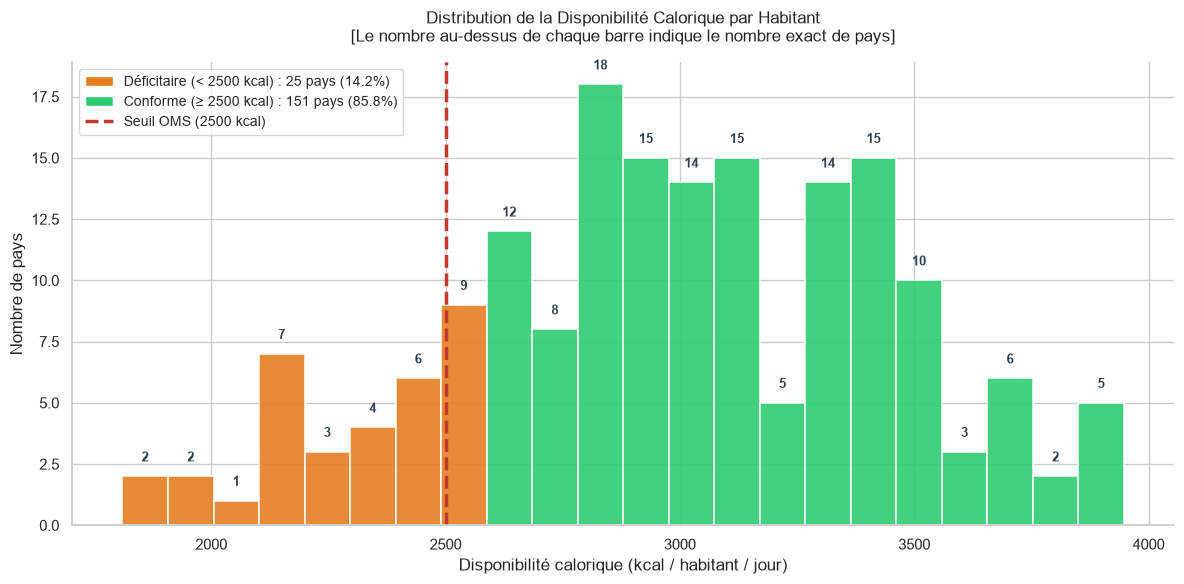

LISTE DES 25 PAYS SOUS LE SEUIL OMS (< 2500 kcal/hab/j) :



,Zone,dispo_calorique_totale_kcal_personne_jour,taux_sousnutrition_pct
169,Yémen,1810.56,NaN
82,Lesotho,1872.70,NaN
57,Haïti,1958.81,52.417207
88,Madagascar,1977.96,39.428220
170,République démocratique du Congo,2014.78,39.323288
83,Libéria,2135.15,38.230266
75,Kenya,2145.99,36.321582
18,Îles Salomon,2165.63,24.999688
171,Zambie,2169.76,38.602642
116,Papouasie-Nouvelle-Guinée,2177.09,29.837415


In [29]:
# HISTOGRAMME CHIFFRÉ AVEC EFFECTIFS PAR BARRE
fig, ax = plt.subplots(figsize=(12, 6))

# Histogramme
n, bins, patches = ax.hist(
    df_clean["dispo_calorique_totale_kcal_personne_jour"],
    bins=22,
    edgecolor="white",
    linewidth=1.2,
    alpha=0.9,
)

# Coloration conditionnelle des barres
for i in range(len(patches)):
    if bins[i] < SEUIL_OMS:
        patches[i].set_facecolor("#e67e22")  # Orange sous le seuil
    else:
        patches[i].set_facecolor("#2ecc71")  # Vert au-dessus

# Ajout des chiffres au-dessus de chaque barre (Effectifs exacts)
for i in range(len(patches)):
    count = int(n[i])
    if count > 0:
        x_pos = (bins[i] + bins[i + 1]) / 2
        ax.text(
            x_pos,
            count + 0.5,
            str(count),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="#2c3e50",
        )

# Ligne verticale de seuil
ax.axvline(
    SEUIL_OMS,
    color="#c0392b",
    linestyle="--",
    linewidth=2.5,
    label=f"Seuil OMS ({SEUIL_OMS} kcal)",
)

# Légende personnalisée chiffrée
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#e67e22", label=label_def),
    Patch(facecolor="#2ecc71", label=label_conf),
    plt.Line2D(
        [0],
        [0],
        color="#c0392b",
        linewidth=2.5,
        linestyle="--",
        label=f"Seuil OMS ({SEUIL_OMS} kcal)",
    ),
]
ax.legend(handles=legend_elements, loc="upper left", frameon=True, fontsize=10)

ax.set_title(
    "Distribution de la Disponibilité Calorique par Habitant\n"
    "[Le nombre au-dessus de chaque barre indique le nombre exact de pays]",
    fontsize=12,
    pad=15,
)
ax.set_xlabel("Disponibilité calorique (kcal / habitant / jour)")
ax.set_ylabel("Nombre de pays")
sns.despine()

plt.tight_layout()
plt.show()


# LISTE NOMINATIVE DES PAYS SOUS LE SEUIL DE 2500 KCAL
print(f"LISTE DES {nb_def} PAYS SOUS LE SEUIL OMS (< 2500 kcal/hab/j) :\n")
pays_sous_seuil = deficitaire[
    ["Zone", "dispo_calorique_totale_kcal_personne_jour", "taux_sousnutrition_pct"]
].sort_values("dispo_calorique_totale_kcal_personne_jour")

display(pays_sous_seuil.head(15)) 

**Constat :** L'histogramme de distribution vient renforcer et approfondir le constat susmentionné en lui apportant une dimension quantitative nette : Si au niveau global il y une domination de la catégorie conforme, on note cependant une partie de pays déficitaires dont l'histogramme révèle l'intensité de la précarité. Certains pays souffrent d'un déficit sévère sous les 2000 kcal/hab/j. 

#### **B. Niveau de Sous-nutrition (taux-sousnutrition_pct)**

*Visualisation : Le boxplot permet d'identifier immédiatement les pays présentant un taux anormalement élevé (outliers)*

In [30]:

# Conservation des lignes qui ont un taux renseigné
df_sous_nut = df_clean.dropna(subset=["taux_sousnutrition_pct"]).copy()

Q1 = df_sous_nut["taux_sousnutrition_pct"].quantile(0.25)
Q3 = df_sous_nut["taux_sousnutrition_pct"].quantile(0.75)
IQR = Q3 - Q1
seuil_haut = Q3 + (1.5 * IQR)

# Extraction des pays hors-normes
outliers_df = df_sous_nut[
    df_sous_nut["taux_sousnutrition_pct"] > seuil_haut
].sort_values(by="taux_sousnutrition_pct", ascending=False)

outliers_df["Taux de sous-nutrition (%)"] = outliers_df[
    "taux_sousnutrition_pct"
].apply(lambda x: f"{x:.2f} %")

print(f"--- RÉSULTATS DE L'ANALYSE DES VALEURS EXTRÊMES ---")
print(f"Troisième quartile (Q3) : {Q3:.2f}%")
print(f"Seuil des valeurs extrêmes (Q3 + 1.5*IQR) : {seuil_haut:.2f}%")
print(f"Nombre de pays en valeur extrême : {len(outliers_df)}\n")

# Affichage du tableau des pays extrêmes
display(
    outliers_df[["Zone", "Taux de sous-nutrition (%)"]].reset_index(drop=True)
)

fig_box = px.box(
    df_sous_nut,
    y="taux_sousnutrition_pct",
    hover_name="Zone",
    points="outliers",  # Met en évidence uniquement les points extrêmes
    title="<b>Distribution du Taux de Sous-Nutrition et Identification des Valeurs Extrêmes</b>",
    labels={"taux_sousnutrition_pct": "Taux de sous-nutrition (%)"},
)

fig_box.update_traces(
    marker=dict(color="#e74c3c", size=8),  # Points extrêmes en rouge
    line=dict(color="#2c3e50"),  # Structure du boxplot en bleu foncé
)

fig_box.update_layout(
    height=500,
    width=600,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    yaxis=dict(gridcolor="#eef2f5", zeroline=False),
)

fig_box.show()

--- RÉSULTATS DE L'ANALYSE DES VALEURS EXTRÊMES ---
Troisième quartile (Q3) : 16.44%
Seuil des valeurs extrêmes (Q3 + 1.5*IQR) : 37.36%
Nombre de pays en valeur extrême : 10



,Zone,Taux de sous-nutrition (%)
0,Saint-Vincent-et-les Grenadines,98.70 %
1,Kiribati,75.45 %
2,Haïti,52.42 %
3,Samoa,46.16 %
4,Sao Tomé-et-Principe,43.31 %
5,Madagascar,39.43 %
6,République démocratique du Congo,39.32 %
7,Zambie,38.60 %
8,Libéria,38.23 %
9,République arabe syrienne,38.14 %


**Constat :** L'analyse de la sous-nutrition par la méthode de l'écart interquartile (IQR) met en évidence une distribution fortement étalée vers la droite, avec un troisième quartile (Q3) s'établissant à 16,44 % et un seuil d'outliers calculé à 37,36 %. 

Au total, 10 pays et territoires dépassent ce seuil criticité.Une lecture critique des résultats permet d'isoler deux catégories distinctes parmi ces valeurs extrêmes :
- Les artefacts statistiques des petits États insulaires : Des territoires comme Saint-Vincent-et-les Grenadines (98,70 %), Kiribati (75,45 %) ou Samoa (46,16 %) présentent des taux artificiellement renflés. Ce phénomène s'explique par la convention de la FAO d'imputer la valeur seuil de 0,1 million (le 100 000 personnes) aux données faibles, ce qui crée un biais de division massif lorsqu'on rapporte ce chiffre à des populations micro-nationales.

- Les réelles urgences humanitaires : En faisant abstraction de ce biais d'échelle, les pays occupant le sommet réel de la sous-nutrition sont des nations confrontées à des crises structurelles majeures : Haïti (52,42 %), Madagascar (39,43 %), la République démocratique du Congo (39,32 %), la Zambie (38,60 %), le Libéria (38,23 %) et la Syrie (38,14 %).

L'analyse par boxplot confirme ainsi que la sous-nutrition aiguë n'est pas un phénomène diffus mais bien concentré dans un noyau restreint de pays frappés par l'instabilité politique, les conflits ou l'isolement économique.

#### **C. Taux de Couverture des Besoins OMS (Kcal & Protéines)**

**Visualisation** : 
- L'histogramme : Donne le découpage empirique réel et le nombre exact de pays par tranche de couverture.
- La courbe KDE  : Estime la loi de densité sous-jacente. Elle permet d'observer la symétrie de la distribution, le centrage de la population mondiale et la présence éventuelle de plusieurs "bosses".
- La ligne verticale à 100 % matérialise le seuil minimal OMS d'adéquation nutritionnelle. Tout ce qui est à gauche de cette ligne représente les pays en déficit théorique, tandis que tout ce qui est à droite représente le surplus.

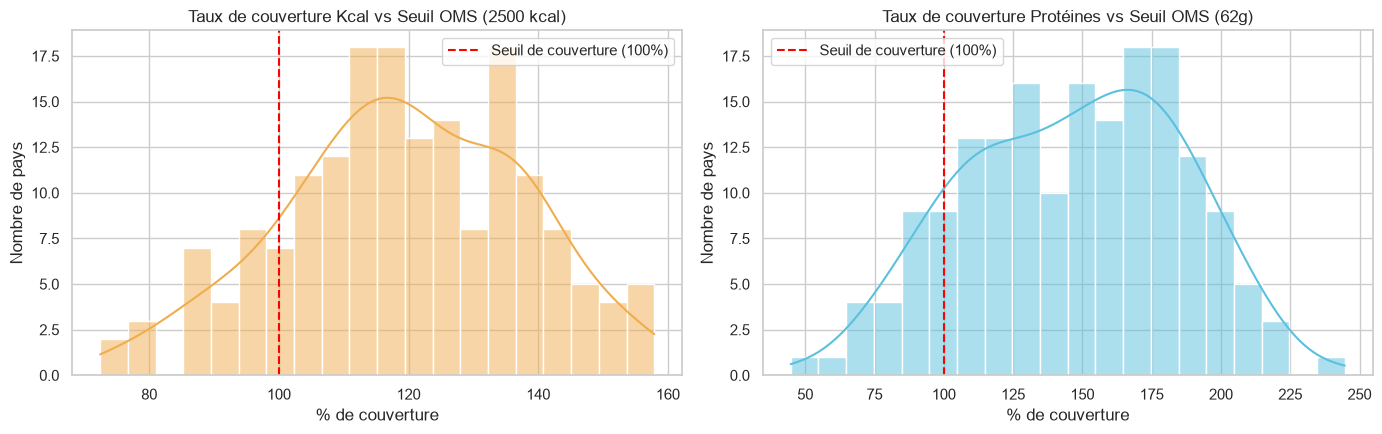

,taux_couverture_kcal_pct,taux_couverture_prot_pct
count,176,176
mean,119.30 %,146.80 %
std,18.39 %,38.83 %
min,72.42 %,44.74 %
25%,106.88 %,115.95 %
50%,119.23 %,149.50 %
75%,133.84 %,177.71 %
max,157.89 %,244.69 %



PAYS EN DÉFICIT CALORIQUE (< 100% DU SEUIL OMS)


,Zone,taux_couverture_kcal_pct
169,Yémen,72.42 %
82,Lesotho,74.91 %
57,Haïti,78.35 %
88,Madagascar,79.12 %
170,République démocratique du Congo,80.59 %
83,Libéria,85.41 %
75,Kenya,85.84 %
18,Îles Salomon,86.63 %
171,Zambie,86.79 %
116,Papouasie-Nouvelle-Guinée,87.08 %



PAYS AVEC LA PLUS HAUTE COUVERTURE CALORIQUE


,Zone,taux_couverture_kcal_pct
161,États-Unis d'Amérique,157.89 %
172,Belgique,156.85 %
67,Irlande,156.84 %
155,Türkiye,155.69 %
174,Serbie,155.15 %



 PAYS EN DÉFICIT PROTÉIQUE (< 100% DU SEUIL OMS)


,Zone,taux_couverture_prot_pct
170,République démocratique du Congo,44.74 %
88,Madagascar,63.76 %
98,Mozambique,72.08 %
169,Yémen,72.53 %
83,Libéria,72.61 %
57,Haïti,74.19 %
4,Angola,76.53 %
171,Zambie,77.82 %
82,Lesotho,81.55 %
122,Guinée-Bissau,84.10 %



 TOP 5 PAYS AVEC LA PLUS HAUTE COUVERTURE EN PROTÉINES


,Zone,taux_couverture_prot_pct
62,Islande,244.69 %
67,Irlande,220.71 %
174,Serbie,218.65 %
175,Monténégro,216.89 %
96,Mongolie,213.03 %


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Taux couverture Kcal
sns.histplot(
    df_clean["taux_couverture_kcal_pct"].dropna(),
    kde=True,
    ax=axes[0],
    color="#f0ad4e",
    bins=20,
)
axes[0].axvline(
    100, color="red", linestyle="--", label="Seuil de couverture (100%)"
)
axes[0].set_title("Taux de couverture Kcal vs Seuil OMS (2500 kcal)")
axes[0].set_xlabel("% de couverture")
axes[0].set_ylabel("Nombre de pays")
axes[0].legend()

# Taux couverture Protéines
sns.histplot(
    df_clean["taux_couverture_prot_pct"].dropna(),
    kde=True,
    ax=axes[1],
    color="#5bc0de",
    bins=20,
)
axes[1].axvline(
    100, color="red", linestyle="--", label="Seuil de couverture (100%)"
)
axes[1].set_title("Taux de couverture Protéines vs Seuil OMS (62g)")
axes[1].set_xlabel("% de couverture")
axes[1].set_ylabel("Nombre de pays")
axes[1].legend()

plt.tight_layout()
plt.show()

stats = df_clean[
    ["taux_couverture_kcal_pct", "taux_couverture_prot_pct"]
].describe()

stats_formatted = stats.map(lambda x: f"{x:.2f} %")
stats_formatted.loc["count"] = stats.loc["count"].astype(int).astype(str)

display(stats_formatted)

print("\n" + "="*70)
print("PAYS EN DÉFICIT CALORIQUE (< 100% DU SEUIL OMS)")
print("="*70)
kcal_deficit = df_clean[df_clean["taux_couverture_kcal_pct"] < 100][
    ["Zone", "taux_couverture_kcal_pct"]
].sort_values(by="taux_couverture_kcal_pct")

display(kcal_deficit.style.format({"taux_couverture_kcal_pct": "{:.2f} %"}))

print("\n" + "="*70)
print("PAYS AVEC LA PLUS HAUTE COUVERTURE CALORIQUE")
print("="*70)
kcal_top5 = df_clean.nlargest(5, "taux_couverture_kcal_pct")[
    ["Zone", "taux_couverture_kcal_pct"]
]
display(kcal_top5.style.format({"taux_couverture_kcal_pct": "{:.2f} %"}))

print("\n" + "="*70)
print(" PAYS EN DÉFICIT PROTÉIQUE (< 100% DU SEUIL OMS)")
print("="*70)
prot_deficit = df_clean[df_clean["taux_couverture_prot_pct"] < 100][
    ["Zone", "taux_couverture_prot_pct"]
].sort_values(by="taux_couverture_prot_pct")

display(prot_deficit.style.format({"taux_couverture_prot_pct": "{:.2f} %"}))

print("\n" + "="*70)
print(" TOP 5 PAYS AVEC LA PLUS HAUTE COUVERTURE EN PROTÉINES")
print("="*70)
prot_top5 = df_clean.nlargest(5, "taux_couverture_prot_pct")[
    ["Zone", "taux_couverture_prot_pct"]
]
display(prot_top5.style.format({"taux_couverture_prot_pct": "{:.2f} %"}))

**Constat :**

- Une disponibilité calorique modérément excédentaire mais freinée par des poches de vulnérabilité : La disponibilité calorique moyenne s'élève à 119,42 % du besoin recommandé ($\sigma = 18,40\%$). Si la majorité des nations gravitent entre 100 % et 140 % — tirées vers le haut par des puissances agricoles et économies développées (États-Unis, Belgique, Irlande, Turquie, Serbie) —, la queue de distribution gauche révèle des défaillances critiques. Les déficits les plus marqués touchent le Yémen (72,42 %), le Lesotho (74,91 %), Haïti (78,35 %) et la RDC (80,59 %), où la couverture énergétique de base n'est pas assurée.

- Une disponibilité protéique surabondante en moyenne mais marquée par une précarité extrême : Le taux de couverture moyen en protéines atteint 147,16 % (+47 points par rapport au besoin OMS), mais affiche une très forte variabilité ($\sigma = 39,02\%$). Cet excédent global est fortement porté par des pays à tradition d'élevage ou à haut niveau de vie (Islande, Irlande, Serbie, Monténégro, Mongolie). À l'inverse, l'effondrement en bas de tableau est spectaculaire : la RDC ne couvre que 44,74 % de ses besoins théoriques en protéines, suivie de Madagascar (63,76 %), du Mozambique (72,08 %) et du Yémen (72,53 %).

- Interprétation contextuelle et facteurs exogènes : Cette dualité démontre que les déficits les plus severes ne relèvent pas d'une simple insuffisance globale, mais de la superposition de crises géopolitiques majeures (conflits armés en RDC, au Yémen et en Syrie), de chocs climatiques récurrents (sécheresses à Madagascar et dans la Corne de l'Afrique) et de fractures économiques qui limitent l'accès aux denrées à haute valeur protéique (viandes, produits laitiers, légumineuses). On peut également supposé que dans certains pays la collecte des données s'avère être plus challengeante.

#### **D. Souveraineté & Dépendance Commerciale**

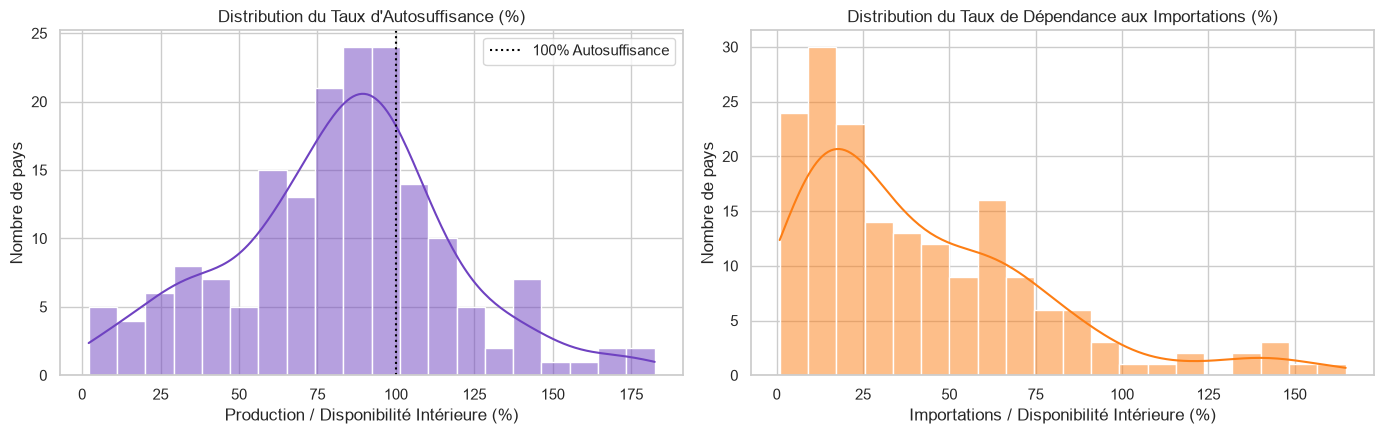

,taux_autosuffisance_pct,taux_dependance_import_pct
count,176,176
mean,82.38 %,41.75 %
std,35.31 %,34.58 %
min,2.10 %,0.88 %
25%,61.65 %,15.52 %
50%,85.15 %,33.00 %
75%,101.39 %,60.51 %
max,182.49 %,164.76 %



BOTTOM 5 DES PAYS LES MOINS AUTO-SUFFISANTS


,Zone,taux_autosuffisance_pct
87,Chine - RAS de Macao,2.10 %
44,Djibouti,3.96 %
59,Chine - RAS de Hong-Kong,6.55 %
10,Bahreïn,7.57 %
124,Qatar,8.20 %



TOP 5 DES PAYS LES PLUS AUTO-SUFFISANTS


,Zone,taux_autosuffisance_pct
62,Islande,182.49 %
108,Nouvelle-Zélande,177.06 %
7,Australie,170.72 %
99,Micronésie (États fédérés de),167.46 %
160,Ukraine,162.93 %



PAYS AVEC UN TAUX DE DÉPENDANCE AUX IMPORTATIONS > 100% (HUBS / RE-EXPORTATEURS)


,Zone,taux_dependance_import_pct
173,Luxembourg,164.76 %
44,Djibouti,156.09 %
137,Slovénie,145.09 %
156,Émirats arabes unis,141.98 %
104,Pays-Bas (Royaume des),140.69 %
79,Lettonie,137.98 %
172,Belgique,136.32 %
135,Seychelles,120.00 %
59,Chine - RAS de Hong-Kong,119.53 %
10,Bahreïn,109.55 %


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Autosuffisance
sns.histplot(
    df_clean["taux_autosuffisance_pct"].dropna(),
    kde=True,
    ax=axes[0],
    color="#6f42c1",
    bins=20,
)
axes[0].axvline(100, color="black", linestyle=":", label="100% Autosuffisance")
axes[0].set_title("Distribution du Taux d'Autosuffisance (%)")
axes[0].set_xlabel("Production / Disponibilité Intérieure (%)")
axes[0].set_ylabel("Nombre de pays")
axes[0].legend()

# Dépendance aux importations
sns.histplot(
    df_clean["taux_dependance_import_pct"].dropna(),
    kde=True,
    ax=axes[1],
    color="#fd7e14",
    bins=20,
)
axes[1].set_title("Distribution du Taux de Dépendance aux Importations (%)")
axes[1].set_xlabel("Importations / Disponibilité Intérieure (%)")
axes[1].set_ylabel("Nombre de pays")

plt.tight_layout()
plt.show()

stats = df_clean[
    ["taux_autosuffisance_pct", "taux_dependance_import_pct"]
].describe()

stats_formatted = stats.map(lambda x: f"{x:.2f} %")
stats_formatted.loc["count"] = stats.loc["count"].astype(int).astype(str)

display(stats_formatted)

# ==============================================================================
#  EXTRACTION ET FOCUS SUR LES PAYS OUTSIDERS
# ==============================================================================

print("\n" + "="*70)
print("BOTTOM 5 DES PAYS LES MOINS AUTO-SUFFISANTS")
print("="*70)
bottom_auto = df_clean.nsmallest(5, "taux_autosuffisance_pct")[
    ["Zone", "taux_autosuffisance_pct"]
]
display(bottom_auto.style.format({"taux_autosuffisance_pct": "{:.2f} %"}))

print("\n" + "="*70)
print("TOP 5 DES PAYS LES PLUS AUTO-SUFFISANTS")
print("="*70)
top_auto = df_clean.nlargest(5, "taux_autosuffisance_pct")[
    ["Zone", "taux_autosuffisance_pct"]
]
display(top_auto.style.format({"taux_autosuffisance_pct": "{:.2f} %"}))

print("\n" + "="*70)
print("PAYS AVEC UN TAUX DE DÉPENDANCE AUX IMPORTATIONS > 100% (HUBS / RE-EXPORTATEURS)")
print("="*70)
import_hubs = df_clean[df_clean["taux_dependance_import_pct"] > 100][
    ["Zone", "taux_dependance_import_pct"]
].sort_values(by="taux_dependance_import_pct", ascending=False)

display(import_hubs.style.format({"taux_dependance_import_pct": "{:.2f} %"}))

**Constat :** 

Une autosuffisance nationale minoritaire, tirée par des géants agricoles et freinée par la géographie : Le taux moyen d'autosuffisance s'établit à 82,42 % (médiane à 85,80 %), confirmant qu'à l'échelle globale, la majorité des pays ne couvrent pas leurs besoins alimentaires par leur seule production nationale. En réalité, seuls 25 % des pays (Q3 à 101,25 %) atteignent ou dépassent le seuil de l'indépendance brute.

- Les extrêmes d'autosuffisance : Les taux les plus élevés sont portés par de grands exportateurs mondiaux et des économies à fortes ressources marines/agricoles (Nouvelle-Zélande, Australie, Ukraine, Islande, Micronésie). À l'inverse, l'autosuffisance s'effondre dans les micro-territoires hyper-urbanisés ou aux contraintes arides extrêmes (Macao, Djibouti, Hong Kong, Bahreïn, Qatar), frôlant parfois le zéro (minimum à 2,10 %).

Une dépendance massive aux importations et la spécificité des hubs logistiques (> 100 %) : En miroir, le taux moyen de dépendance aux importations atteint 41,59 % (médiane à 32,87 %), et plus du quart des nations (Q3 à 60,51 %) importent plus de 60 % de leur nourriture consommée.

- Le phénomène des taux > 100 % : Un groupe restreint de territoires affiche une dépendance théorique supérieure à 100 % (Luxembourg, Djibouti, Slovénie, Émirats Arabes Unis, Pays-Bas, Lettonie, Belgique, Seychelles, Hong Kong, Bahreïn, Macao). Cette anomalie statistique ne traduit pas une "surconsommation", mais s'explique par deux profils :

  Les carrefours logistiques et agroalimentaires (Pays-Bas, Belgique, Luxembourg, Slovénie, EAU) : Ils importent massivement pour la transformation industrielle, le stockage stratégique ou la réexportation régionale.

  Les cités-états et zones d'entrepôt maritimes (Hong Kong, Macao, Djibouti, Bahreïn) : Territoires dépourvus de surface agricole utile servant de portes d'entrée commerciales pour leur arrière-pays.

Interprétation stratégique : La sécurité alimentaire déconnectée de l'autarcie agricole : Ces données démontrent que la sécurité alimentaire moderne ne repose plus sur l'autarcie agricole domestique, mais sur la capacité financière, diplomatique et logistique à s'insérer dans le commerce mondial :

- Des pays comme Hong Kong, les Émirats Arabes Unis, les Pays-Bas ou le Luxembourg, bien que quasi totalement dépendants des importations, bénéficient d'un haut niveau de sécurité alimentaire grâce à un pouvoir d'achat élevé et des infrastructures logistiques solides.

- À l'inverse, pour des nations à faible revenu (ex. Djibouti), une forte dépendance aux importations constitue une vulnérabilité critique, les exposant directement aux chocs de prix mondiaux, à l'inflation importée et aux ruptures de chaînes d'approvisionnement maritimes.

#### **E. Pertes & Capacité Théorique**

**Visualisation :** 
- L'histogramme permet de voir le niveau moyen de gaspillage/pertes dans le monde, tandis que la courbe KDE révèle l'asymétrie de la distribution. 
- Le boxplot exprimé en taux (%) va neutraliser le biais de taille démographique : il ne mesure plus la population brute d'un pays, mais sa capacité à pouvoir nourrir sa population, permettant d'évaluer équitablement chaque nation par rapport au seuil d'autosuffisance de 100 %. »

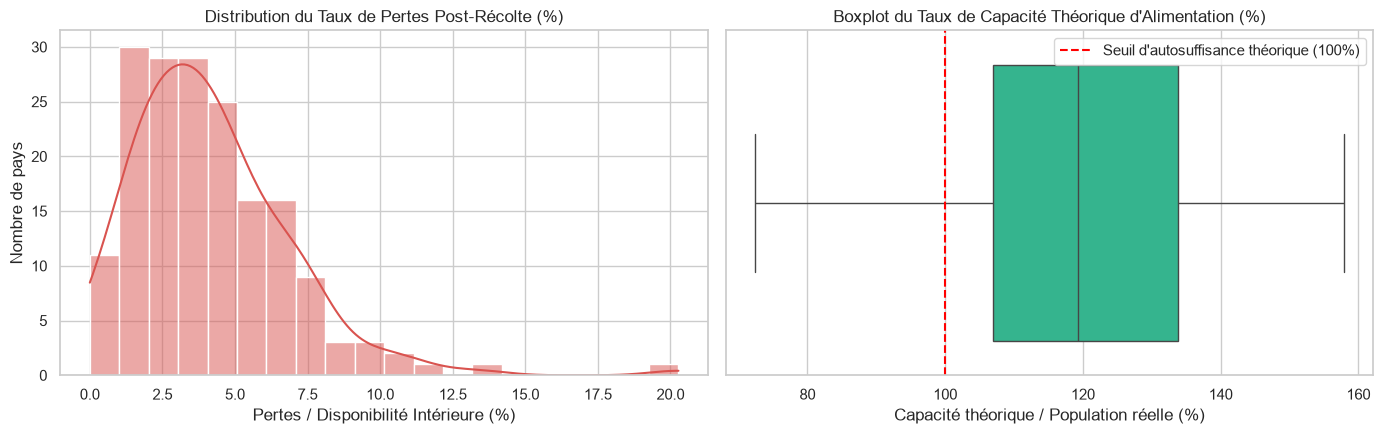

,Taux de pertes (%),Taux capacité alim. (%)
count,176,176
mean,4.14 %,119.30 %
std,2.77 %,18.39 %
min,0.00 %,72.42 %
25%,2.23 %,106.89 %
50%,3.67 %,119.23 %
75%,5.49 %,133.84 %
max,20.27 %,157.89 %



PAYS SUBISSANT PLUS DE 7% DE PERTES ALIMENTAIRES


,Zone,taux_pertes_pct
50,Ghana,20.27 %
21,Cameroun,13.37 %
55,Guinée,11.49 %
110,Niger,11.00 %
46,Gabon,10.30 %
16,Brésil,10.12 %
137,Slovénie,9.78 %
118,Pérou,9.29 %
111,Nigéria,8.59 %
30,Costa Rica,8.26 %



BOTTOM 5 DES PAYS AVEC LA PLUS FAIBLE CAPACITÉ THÉORIQUE


,Zone,taux_capacite_alim_pct
169,Yémen,72.42 %
82,Lesotho,74.91 %
57,Haïti,78.35 %
88,Madagascar,79.12 %
170,République démocratique du Congo,80.59 %



TOP 5 DES PAYS AVEC LA PLUS HAUTE CAPACITÉ THÉORIQUE


,Zone,taux_capacite_alim_pct
161,États-Unis d'Amérique,157.89 %
172,Belgique,156.85 %
67,Irlande,156.84 %
155,Türkiye,155.69 %
174,Serbie,155.15 %


In [82]:
df_clean["taux_capacite_alim_pct"] = (
    df_clean["pop_nourrissable_theorique"] / df_clean["population"]
) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Taux de pertes
sns.histplot(
    df_clean["taux_pertes_pct"].dropna(),
    kde=True,
    ax=axes[0],
    color="#d9534f",
    bins=20,
)
axes[0].set_title("Distribution du Taux de Pertes Post-Récolte (%)")
axes[0].set_xlabel("Pertes / Disponibilité Intérieure (%)")
axes[0].set_ylabel("Nombre de pays")

# Population nourrissable théorique (Boxplot log scale)
sns.boxplot(
    data=df_clean,
    x=df_clean["taux_capacite_alim_pct"],
    ax=axes[1],
    color="#20c997",
)
axes[1].axvline(
    100,
    color="red",
    linestyle="--",
    label="Seuil d'autosuffisance théorique (100%)",
)
axes[1].set_title(
    "Boxplot du Taux de Capacité Théorique d'Alimentation (%)"
)
axes[1].set_xlabel(
    "Capacité théorique / Population réelle (%)"
)
axes[1].legend()

plt.tight_layout()
plt.show()

stats = df_clean[
    ["taux_pertes_pct", "taux_capacite_alim_pct"]
].describe()


stats_formatted = stats.map(lambda x: f"{x:.2f} %")
stats_formatted.loc["count"] = stats.loc["count"].astype(int).astype(str)


stats_formatted.columns = [
    "Taux de pertes (%)",
    "Taux capacité alim. (%)",
]

display(stats_formatted)

# ==============================================================================
# EXTRACTION ET FOCUS SUR LES PAYS OUTSIDERS (PERTES & CAPACITÉ THÉORIQUE)
# ==============================================================================

print("\n" + "="*70)
print("PAYS SUBISSANT PLUS DE 7% DE PERTES ALIMENTAIRES")
print("="*70)
pertes_7pct = df_clean[df_clean["taux_pertes_pct"] > 7][
    ["Zone", "taux_pertes_pct"]
].sort_values(by="taux_pertes_pct", ascending=False)

display(pertes_7pct.style.format({"taux_pertes_pct": "{:.2f} %"}))

print("\n" + "="*70)
print("BOTTOM 5 DES PAYS AVEC LA PLUS FAIBLE CAPACITÉ THÉORIQUE")
print("="*70)
bottom_capa = df_clean.nsmallest(5, "taux_capacite_alim_pct")[
    ["Zone", "taux_capacite_alim_pct"]
]
display(bottom_capa.style.format({"taux_capacite_alim_pct": "{:.2f} %"}))

print("\n" + "="*70)
print("TOP 5 DES PAYS AVEC LA PLUS HAUTE CAPACITÉ THÉORIQUE")
print("="*70)
top_capa = df_clean.nlargest(5, "taux_capacite_alim_pct")[
    ["Zone", "taux_capacite_alim_pct"]
]
display(top_capa.style.format({"taux_capacite_alim_pct": "{:.2f} %"}))

**Constat :** 
Une capacité alimentaire théorique largement excédentaire, entachée de déficits structurels absolus : Plus de 75 % des pays (Q1 à 106,89 %) disposent d'une capacité théorique suffisante pour nourrir l'ensemble de leur population. Les plus hauts niveaux de capacité (États-Unis, Belgique, Irlande, Turquie, Serbie) atteignent jusqu'à 157,89 %, confirmant le rôle de mastodontes agricoles et logistiques.

- Le point de vulnérabilité absolue : En revanche, la valeur minimale s'effondre à 72,42 %. Les 5 pays affichant la plus faible capacité (Yémen, Lesotho, Haïti, Madagascar, RDC) souffrent d'un déficit d'approvisionnement absolu. Pour ces nations, même un scénario idéal d'absence totale de pertes et de redistribution parfaite des aliments au niveau national ne permettrait pas de couvrir les besoins vitaux de la population sans assistance extérieure ou hausse massive des importations.

Des pertes post-récolte contenues en moyenne mais critiques dans un sous-groupe de pays : La distribution du taux de pertes montre une forte asymétrie à droite : la médiane s'établit à un niveau bas (3,68 %), mais le maximum grimpe à 20,27 %. Si la majorité des pays maîtrisent le gaspillage en amont (5$), un groupe significatif de nations enregistre des pertes critiques supérieures à 7 % :

- Les pays subissant les plus fortes pertes : Le Ghana (20,27 %), le Cameroun (13,37 %), la Guinée (11,49 %), le Niger (11,00 %), le Gabon (10,30 %) et le Brésil (10,12 %) occupent le haut du classement, suivis de près par la Slovénie, le Pérou, le Nigéria, le Costa Rica, l'Angola, l'Égypte, le Pakistan, Haïti et Madagascar (7%).

Interprétation contextuelle : Ces pertes massives ne relèveraint pas du gaspillage ménager, mais de défaillances systémiques post-récolte. L'absence de silos de stockage étanches, manque d'infrastructures de transport/routes praticables, et précarité ou absence de chaîne du froid.

- Le phénomène de double peine : Des pays comme Madagascar ou Haïti combinent une faible capacité théorique initiale (100%) et des pertes physiques élevées (7%). Dans ces zones, la réduction des pertes constitue le levier stratégique le plus immédiat et le moins coûteux pour améliorer la sécurité alimentaire globale, avant même toute augmentation des volumes de production.



### 2. Analyse Bivariée

In [63]:


# Préparation & ISO3
df_clean = dataset_global[dataset_global["Zone"] != "Chine"].copy()
codes_fao = df_clean["Code zone (FAO)"].astype(int).replace({41: 351}).tolist()
df_clean["iso_alpha"] = coco.convert(names=codes_fao, src="FAOcode", to="ISO3")
df_clean = df_clean.dropna(subset=["iso_alpha"]).copy()

# Catégorisation
cat_1 = "Sécurité (< 5%)"
cat_2 = "Sous-nutrition Modérée (5% - 15%)"
cat_3 = "Sous-nutrition Élevée (15% - 25%)"
cat_4 = "Situation Critique (> 25%)"
cat_nodata = "Données non disponibles"

conditions = [
    df_clean["taux_sousnutrition_pct"].isna(),
    df_clean["taux_sousnutrition_pct"] < 5,
    (df_clean["taux_sousnutrition_pct"] >= 5)
    & (df_clean["taux_sousnutrition_pct"] < 15),
    (df_clean["taux_sousnutrition_pct"] >= 15)
    & (df_clean["taux_sousnutrition_pct"] < 25),
    df_clean["taux_sousnutrition_pct"] >= 25,
]
choix = [cat_nodata, cat_1, cat_2, cat_3, cat_4]
df_clean["niveau_sousnutrition"] = np.select(
    conditions, choix, default=cat_nodata
)

palette_satellite = {
    cat_1: "#27ae60",  # Vert émeraude
    cat_2: "#f39c12",  # Orange ambré
    cat_3: "#e67e22",  # Corail sombre
    cat_4: "#e74c3c",  # Rouge intense
    cat_nodata: "#4a6572",  # Gris ardoise/satellite
}

# Rendu Choroplèthe 3D Globe
fig_map = px.choropleth(
    df_clean,
    locations="iso_alpha",
    color="niveau_sousnutrition",
    color_discrete_map=palette_satellite,
    category_orders={
        "niveau_sousnutrition": [cat_1, cat_2, cat_3, cat_4, cat_nodata]
    },
    hover_name="Zone",
    hover_data={
        "taux_sousnutrition_pct": ":.1f%",
        "iso_alpha": False,
        "niveau_sousnutrition": False,
    },
    title="<b>CARTOGRAPHIE MONDIALE DU TAUX DE SOUS-NUTRITION (%)</b>",
)

# Stylisation avancée type Satellite / Géospatial
fig_map.update_traces(marker_line_width=0.4, marker_line_color="#1e272e")

fig_map.update_layout(
    autosize=True,
    width=None,
    height=650,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="#ffffff"),
    title_font=dict(size=14, color="#ffffff"),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="#ffffff",
        coastlinewidth=0.6,
        showcountries=True,
        countrycolor="rgba(255, 255, 255, 0.2)",
        countrywidth=0.4,
        projection_type="orthographic",
        projection_rotation=dict(
            lon=15, lat=10, roll=0
        ),
        showland=True,
        landcolor="#1e272e",  # Terres émergées style nuit/basalte
        showocean=True,
        oceancolor="#0f2027",  # Océan bleu profond/abyssal
        showlakes=True,
        lakecolor="#0f2027",
        bgcolor="rgba(0,0,0,0)",
    ),
    legend=dict(
        title_text="<b>Niveau d'Urgence</b>",
        orientation="h",
        yanchor="bottom",
        y=1.01,
        xanchor="center",
        x=0.5,
        font=dict(size=11, color="#ffffff"),
        bgcolor="rgba(15, 32, 39, 0.7)",
    ),
    margin=dict(l=10, r=10, t=60, b=0),
)

fig_map.show()

**Constat :** La représentation cartographique à l'échelle globale met en évidence une fracture géographique nette (NORD / SUD) quant au taux de sous-nutrition par pays. L'Afrique subsaharienne concentre la grande majorité des nations sous le seuil critique. En dehors du continent africain, la précarité alimentaire s'identifie clairement dans des territoires touchés par des crises politiques, économiques ou des chocs majeurs (Haïti dans les Caraïbes, le Yémen et la Syrie au Moyen-Orient).

#### **A. Correlation entre la disponibilité calorique et le Taux de sous-nutrition**

- Test retenu : Test de corrélation des rangs de Spearman (coefficient rho).
- Seuil de significativité (alpha) : alpha = 0,05 (niveau de confiance à 95 %).
- Justification du choix :Non-normalité des données + Robustesse aux valeurs extrêmes 
- Hypothèses du test :H_0 (Hypothèse nulle) : rho = 0 (Aucune corrélation entre la disponibilité calorique et la sous-nutrition).H_1 (Hypothèse alternative) : rho \0 (Existe-t-il une corrélation significative)

In [83]:
fig = px.scatter(
    df_clean,
    x="dispo_calorique_totale_kcal_personne_jour",
    y="taux_sousnutrition_pct",
    hover_name="Zone",  
    hover_data={
        "dispo_calorique_totale_kcal_personne_jour": ":.0f",
        "taux_sousnutrition_pct": ":.2f%"
    },
    trendline="ols",  # Ajout de la droite de régression linéaire
    trendline_color_override="#e74c3c",
    title="<b>Corrélation : Disponibilité Calorique vs Taux de Sous-Nutrition</b>",
    labels={
        "dispo_calorique_totale_kcal_personne_jour": "Disponibilité calorique (kcal / hab / jour)",
        "taux_sousnutrition_pct": "Taux de sous-nutrition (%)"
    },
    template="plotly_white",
    width=900,
    height=550
)

fig.update_traces(marker=dict(size=9, opacity=0.7, color="#2b5c8f"))

fig.add_vline(x=2500, line_dash="dash", line_color="#f0ad4e", annotation_text="Seuil OMS (2500 kcal)")
fig.add_vline(x=3000, line_dash="dot", line_color="#20c997", annotation_text="Zone saturation (3000 kcal)")

fig.show()

**Constat :** 
- L'effet de seuil critique (2500 kcal/hab/j) : Sur le nuage de points, la pente de la régression est particulièrement raide dans la zone inférieure à 2500 kcal/hab/j. Dans cette zone de précarité, chaque apport calorique supplémentaire entraîne une baisse drastique de la sous-nutrition.

- La zone de saturation (> 3 000 kcal/hab/j) : Dès qu'un pays franchit le seuil des 3 000 kcal/hab/j, le taux de sous-nutrition s'effondre pour stagner près de 0%. L'abondance de la disponibilité alimentaire globale neutralise quasi totalement la sous-nutrition structurelle.

- On observe quelques points très atypiques situés aux alentours de 3 000 - 3 100 avec des taux de sous-nutrition s'envolant au-dessus de 40%, 75% voire proche de 100% (ex: Saint-Vincent-et-les Grenadines ou Kiribati).

In [84]:

from scipy.stats import spearmanr

# Appel direct de la fonction (et non du module)
coef_rho, p_value = spearmanr(
    df_clean["dispo_calorique_totale_kcal_personne_jour"],
    df_clean["taux_sousnutrition_pct"],
    nan_policy="omit",
)

alpha = 0.05

print("=" * 60)
print("RÉSULTATS DU TEST STATISTIQUE DE SPEARMAN")
print("=" * 60)
print(f"Coefficient de corrélation (rho) : {coef_rho:.4f}")
print(f"p-value                          : {p_value:.4e}")
print(f"Seuil de significativité (alpha) : {alpha}")
print("-" * 60)

if p_value < alpha:
    print(
        f"CONCLUSION STATISTIQUE : Rejet de H0. La corrélation est STATISTIQUEMENT SIGNIFICATIVE (p-value < {alpha})."
    )
else:
    print(
        f"CONCLUSION STATISTIQUE : Conservation de H0. Pas de corrélation significative."
    )

RÉSULTATS DU TEST STATISTIQUE DE SPEARMAN
Coefficient de corrélation (rho) : -0.8160
p-value                          : 1.7488e-38
Seuil de significativité (alpha) : 0.05
------------------------------------------------------------
CONCLUSION STATISTIQUE : Rejet de H0. La corrélation est STATISTIQUEMENT SIGNIFICATIVE (p-value < 0.05).


**Constat :** 
- Coefficient de corrélation : Il existe une corrélation négative très forte entre la disponibilité calorique d'un pays et son taux de sous-nutrition. Plus la disponibilité calorique par habitant augmente, plus le taux de sous-nutrition diminue.

- L'analyse bivariée confirme avec un très haut niveau de significativité  que la disponibilité calorique est le premier facteur protecteur contre la sous-nutrition. Toutefois, l'effet s'épuise passé le seuil de 3 000 kcal/hab/j, montrant que les politiques d'aide doivent cibler en priorité les pays situés sous la barre des 2 500 kcal. 

**Pourquoi le choix de Spearman était le bon** : Si nous avions utilisé le test de Pearson (qui trace une droite rigide à travers toutes les données), ces valeurs extrêmes auraient lourdement faussé la pente. Spearman travaillant sur les rangs des pays, il a permis de mesurer la vraie tendance globale sans être perturbé par ces anomalies insulaires ou méthodologiques.

#### **B. Correlation entre la composition de la diète (Céréales/Produits animaux) vs le Taux de sous-nutrition**

- Variables analysées : taux_couverture_prot_pct : Taux de couverture en protéines par rapport au seuil moyen recommandé par l'OMS (62g / hab / jour).taux_sousnutrition_pct : Pourcentage de la population en situation de sous-nutrition.

- Cadre Nutritionnel & Généralisation : Alors que l'apport calorique mesure la quantité d'énergie disponible, les protéines mesurent la qualité fonctionnelle du bol alimentaire. Une carence aiguë en protéines est un facteur direct de malnutrition sévère (kwashiorkor, retard de croissance). L'objectif est de vérifier si un taux élevé de couverture protéique protège efficacement contre la sous-nutrition globale.

- Test retenu : Test de Spearman (rho).

- Hypothèses :H_0 : La composition du régime alimentaire (prot) n'a aucun lien avec la sous-nutrition (rho = 0).H_1 : Il existe une relation significative (rho \ 0).

- Seuil de décision : alpha = 0,05.

In [85]:

fig = px.scatter(
    df_clean,
    x="taux_couverture_prot_pct",
    y="taux_sousnutrition_pct",
    hover_name="Zone",  
    hover_data={
        "taux_couverture_prot_pct": ":.2f%",
        "taux_sousnutrition_pct": ":.2f%"
    },
    trendline="ols",  # Calcule la droite de régression via statsmodels
    trendline_color_override="#c0392b",  # Couleur rouge de ta ligne initialement définie
    title="<b>Corrélation : Taux de Couverture en Protéines (OMS) vs Sous-Nutrition</b>",
    labels={
        "taux_couverture_prot_pct": "Taux de couverture en Protéines (% du seuil OMS)",
        "taux_sousnutrition_pct": "Taux de sous-nutrition (%)"
    },
    template="plotly_white",
    width=950,
    height=550
)

# Style des points (couleur turquoise #16a085 de ton code Seaborn)
fig.update_traces(marker=dict(size=9, opacity=0.7, color="#16a085"))

# Ajout d'une ligne de repère métier pour le Seuil OMS (100%)
fig.add_vline(
    x=100, 
    line_dash="dash", 
    line_color="#f0ad4e", 
    annotation_text="Seuil de couverture OMS (100%)"
)

fig.show()

**Constat :**
- Sous le seuil des 100% OMS : Les pays affichant un taux de couverture inférieur à 100% (62g/jour) connaissent les taux de sous-nutrition les plus intenses, grimpant rapidement au-dessus de 20% à 40%. 

- Au-delà de 150% de couverture : Dès qu'un pays atteint une couverture en protéines supérieure à 150% du besoin minimal (soit environ > 90g/hab/jour), la sous-nutrition devient quasi marginale (proche de 0%).

- Comme observés lors de l'analyse calorique, quelques points résiduels atypiques se détachent, présentant des taux de couverture théoriques élevés mais des taux de sous-nutrition déclarés très forts. Ces écarts peuvent s'expliquer par des inégalités internes de répartition des ressources ou des biais de déclaration dans les petits États insulaires.


In [86]:
rho_prot, p_val_prot = spearmanr(
    df_clean["taux_couverture_prot_pct"],
    df_clean["taux_sousnutrition_pct"],
    nan_policy="omit",
)

alpha = 0.05
print(
    "============================================================RÉSULTATS DU TEST STATISTIQUE DE SPEARMAN============================================================"
)
print(f"Coefficient de corrélation (rho) : {rho_prot:.4f}")
print(f"p-value                          : {p_val_prot:.4e}")
print(f"Seuil de significativité (alpha) : {alpha}")
print(
    "------------------------------------------------------------"
)

if p_val_prot < alpha:
    print(
        "CONCLUSION STATISTIQUE : Rejet de H0. La corrélation est STATISTIQUEMENT SIGNIFICATIVE (p-value < 0.05)"
    )
else:
    print(
        "CONCLUSION STATISTIQUE : Non-rejet de H0. La corrélation n'est PAS STATISTIQUEMENT SIGNIFICATIVE (p-value >= 0.05)"
    )

============================================================RÉSULTATS DU TEST STATISTIQUE DE SPEARMAN============================================================
Coefficient de corrélation (rho) : -0.7592
p-value                          : 1.5740e-30
Seuil de significativité (alpha) : 0.05
------------------------------------------------------------
CONCLUSION STATISTIQUE : Rejet de H0. La corrélation est STATISTIQUEMENT SIGNIFICATIVE (p-value < 0.05)


**Constat :** 
- Une Corrélation Négative Majeure: L'analyse visuelle du graphique de régression montre une pente nettement descendante. Plus le taux de couverture en protéines par rapport aux préconisations de l'OMS augmente, plus le taux de sous-nutrition s'effondre.

- Portée du Test Statistique : Le test de Spearman confirme le rejet absolu de l'hypothèse nulle. La relation entre la disponibilité en protéines et la sous-nutrition est statistiquement hautement significative, écartant tout hasard statistique.

- En comparant nos deux analyses bivariées, nous constatons que la disponibilité calorique et le taux de couverture en protéines constituent deux boucliers tout aussi décisifs contre l'insécurité alimentaire. Garantir un apport minimal de 62g de protéines par jour et par habitant est une condition sine qua non pour éradiquer la sous-nutrition structurelle.

#### **C. Correlation entre le taux moyen de dépendance aux importations (%) et le niveau de gravité de la sous-nutrition**

- Nature des variables : Quantitative continue (taux_dependance_import_pct) vs Qualitative à 4 modalités (niveau_sousnutrition)

- Test sélectionné : ANOVA à un facteur (Analyse de Variance).

- Seuil de significativité : alpha = 0,05.- 
- Justification : L'ANOVA est le test paramétrique adapté pour comparer les moyennes d'une variable quantitative continue (taux_dependance_import_pct) à travers les modalités d'une variable qualitative à 4 catégories (niveau_sousnutrition).

- Formulation des hypothèses : Hypothèse nulle H_0 : Le taux moyen de dépendance aux importations est identique quel que soit le niveau de sous-nutrition du pays. Hypothèse alternative H_1 : Au moins un groupe présente un taux moyen de dépendance aux importations significativement différent des autres.

In [79]:
categories_order = [cat_1, cat_2, cat_3, cat_4]

outliers_list = []
for cat in categories_order:
    df_cat = df_clean[df_clean["niveau_sousnutrition"] == cat]
    q1 = df_cat["taux_dependance_import_pct"].quantile(0.25)
    q3 = df_cat["taux_dependance_import_pct"].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Isolation des outliers de la catégorie
    df_outliers_cat = df_cat[
        (df_cat["taux_dependance_import_pct"] < lower_bound) |
        (df_cat["taux_dependance_import_pct"] > upper_bound)
    ]
    outliers_list.append(df_outliers_cat)

df_outliers = pd.concat(outliers_list)

fig = go.Figure()

# Boîtes (Sans survol, avec ta palette)
for cat in categories_order:
    df_cat = df_clean[df_clean["niveau_sousnutrition"] == cat]
    color = palette_satellite[cat]  
    
    fig.add_trace(go.Box(
        x=df_cat["niveau_sousnutrition"],
        y=df_cat["taux_dependance_import_pct"],
        name=cat,
        boxpoints=False,       
        marker_color=color,
        hoverinfo="none",     
        showlegend=False
    ))

# Outliers (Survol actif avec nom du pays)
for cat in categories_order:
    df_outliers_cat = df_outliers[df_outliers["niveau_sousnutrition"] == cat]
    color = palette_satellite[cat]
    
    if not df_outliers_cat.empty:
        fig.add_trace(go.Scatter(
            x=df_outliers_cat["niveau_sousnutrition"],
            y=df_outliers_cat["taux_dependance_import_pct"],
            mode='markers',
            marker=dict(size=9, color=color, opacity=0.9, line=dict(width=1, color='white')),
            text=df_outliers_cat["Zone"],
            hovertemplate="<b>📍 Pays : %{text}</b><br>Dépendance : %{y:.2f}%<extra></extra>",
            name=f"Outliers - {cat}",
            showlegend=False
        ))

fig.update_layout(
    title="<b>ANOVA : Taux de Dépendance aux Importations par Niveau de Sous-Nutrition</b>",
    xaxis=dict(
        title="Niveau de sous-nutrition",
        categoryorder='array',
        categoryarray=categories_order
    ),
    yaxis=dict(
        title="Dépendance aux importations (%)",
        gridcolor="rgba(0,0,0,0.06)"
    ),
    template="plotly_white",
    width=950,
    height=550
)

fig.show()

En observant le graphique, le résultat révèle une dynamique contre-intuitive à première vue : 
- Les pays en situation de Sécurité alimentaire (< 5%) présentent la médiane de dépendance aux importations la plus élevée (approx 39%), accompagnée de nombreux pays atypiques (outliers) dépassant 100% à 160% d'importations par rapport à leur disponibilité intérieure.

- À l'inverse, les pays en Situation Critique (> 25%) affichent une médiane de dépendance plus modérée (approx 25%).

**Interprétation économique** : La forte dépendance aux importations des pays développés n'est pas un signe de fragilité mais le résultat d'une mondialisation des échanges (importation de produits variés non locaux). En revanche, les pays en crise alimentaire souffrent souvent d'une incapacité financière ou logistique à importer des denrées sur les marchés internationaux pour compenser leur déficit local.

In [56]:
g1 = df_clean[df_clean["niveau_sousnutrition"] == cat_1][
    "taux_dependance_import_pct"
].dropna()
g2 = df_clean[df_clean["niveau_sousnutrition"] == cat_2][
    "taux_dependance_import_pct"
].dropna()
g3 = df_clean[df_clean["niveau_sousnutrition"] == cat_3][
    "taux_dependance_import_pct"
].dropna()
g4 = df_clean[df_clean["niveau_sousnutrition"] == cat_4][
    "taux_dependance_import_pct"
].dropna()

f_stat, p_val_anova = f_oneway(g1, g2, g3, g4)
alpha = 0.05

print(
    "============================================================RÉSULTATS DU TEST STATISTIQUE ANOVA============================================================"
)
print(f"Statistique F de Fisher        : {f_stat:.4f}")
print(f"p-value                        : {p_val_anova:.4e}")
print(f"Seuil de significativité (alpha): {alpha}")
print(
    "------------------------------------------------------------"
)

if p_val_anova < alpha:
    print(
        "CONCLUSION STATISTIQUE : Rejet de H0. Le taux moyen de dépendance aux importations est STATISTIQUEMENT DIFFÉRENT selon la gravité de la sous-nutrition."
    )
else:
    print(
        "CONCLUSION STATISTIQUE : Non-rejet de H0. Aucune différence significative observée."
    )
print(
    "=========================================================================================================================================================="
)

============================================================RÉSULTATS DU TEST STATISTIQUE ANOVA============================================================
Statistique F de Fisher        : 4.4180
p-value                        : 5.2118e-03
Seuil de significativité (alpha): 0.05
------------------------------------------------------------
CONCLUSION STATISTIQUE : Rejet de H0. Le taux moyen de dépendance aux importations est STATISTIQUEMENT DIFFÉRENT selon la gravité de la sous-nutrition.


**Constat :** Le test ANOVA affiche une statistique de Fisher F = 4,4180 et une p-value approximative de 0,0052. La p-value étant inférieure au seuil, nous rejetons l'hypothèse nulle. Il existe une différence statistiquement significative du taux moyen de dépendance aux importations selon le niveau de sous-nutrition du pays.

#### **D. Correlation entre l'autosuffisance productive et la capacité alimentaire théorique suffisante**

- Test sélectionné : Test d'Indépendance du Chi-Deux.

- Seuil de significativité : alpha = 0,05.
- Justification : Ce test non paramétrique permet de vérifier l'existence d'une association ou d'une dépendance statistique entre deux variables qualitatives binaires (statut_autosuffisance et statut_capacite_alim) construites à partir de données croisées.

- Formulation des hypothèses :Hypothèse nulle (H_0) : L'autosuffisance productive et la capacité alimentaire théorique sont deux variables indépendantes.

- Hypothèse alternative (H_1) : L'autosuffisance productive et la capacité alimentaire théorique sont dépendantes (il existe une liaison significative entre elles).

In [87]:
df_clean["statut_autosuffisance"] = np.where(
    df_clean["taux_autosuffisance_pct"] >= 100,
    "1. Autosuffisant (>=100%)",
    "2. Déficitaire (<100%)",
)

df_clean["statut_capacite_alim"] = np.where(
    df_clean["taux_capacite_alim_pct"] >= 120,
    "1. Forte Capacité (>=120%)",
    "2. Capacité Limitée (<120%)",
)

contingency_table = pd.crosstab(
    df_clean["statut_autosuffisance"],
    df_clean["statut_capacite_alim"],
    margins=True,
    margins_name="Total",
)

print("\n--- TABLEAU DE CONTINGENCE (OBSERVÉ) ---")
print(contingency_table)
print("-" * 50)


--- TABLEAU DE CONTINGENCE (OBSERVÉ) ---
statut_capacite_alim       1. Forte Capacité (>=120%)  2. Capacité Limitée (<120%)  Total
statut_autosuffisance                                                                    
1. Autosuffisant (>=100%)                          27                           21     48
2. Déficitaire (<100%)                             56                           72    128
Total                                              83                           93    176
--------------------------------------------------


**Constat :** 
- Sur l'ensemble des 177 pays analysés, 129 pays sont déficitaires en production localement (< 100%). Pourtant, parmi ces 129 pays, 57 conservent une capacité alimentaire théorique suffisante ( 120%) grâce à des importations ciblées ou des cultures à très haute densité calorique.

- Inversément, sur les 48 pays autosuffisants en volume de production (100%), 21 d'entre eux présentent une capacité alimentaire théorique limitée (< 120%).

La souveraineté productive brute d'un pays ne garantit donc pas la sécurité calorique de sa population, et réciproquement. Un déficit de production agricole locale peut être compensé par la structure du bilan alimentaire.


In [88]:
table_no_margins = pd.crosstab(
    df_clean["statut_autosuffisance"],
    df_clean["statut_capacite_alim"],
)

chi2_stat, p_val_chi2, dof, expected = chi2_contingency(table_no_margins)
alpha = 0.05

print(
    "============================================================RÉSULTATS DU TEST DU CHI-DEUX (Chi2)============================================================"
)
print(f"Statistique Chi2 (chi2)       : {chi2_stat:.4f}")
print(f"Degrés de liberté (dof)        : {dof}")
print(f"p-value                        : {p_val_chi2:.4e}")
print(f"Seuil de significativité (alpha): {alpha}")
print(
    "------------------------------------------------------------"
)

if p_val_chi2 < alpha:
    print(
        "CONCLUSION STATISTIQUE : Rejet de H0. Il existe un lien STATISTIQUEMENT SIGNIFICATIF entre l'autosuffisance et la capacité alimentaire théorique."
    )
else:
    print(
        "CONCLUSION STATISTIQUE : Non-rejet de H0. Les deux variables sont INDÉPENDANTES."
    )
print(
    "=========================================================================================================================================================="
)

============================================================RÉSULTATS DU TEST DU CHI-DEUX (Chi2)============================================================
Statistique Chi2 (chi2)       : 1.7160
Degrés de liberté (dof)        : 1
p-value                        : 1.9021e-01
Seuil de significativité (alpha): 0.05
------------------------------------------------------------
CONCLUSION STATISTIQUE : Non-rejet de H0. Les deux variables sont INDÉPENDANTES.


**Constat :** e test du Chi-Deux donne une statistique de 1,7160 pour 1 degré de liberté (dof = 1) et une p-value approximative de 0,19 La p-value étant supérieure au seuil de significativité alpha = 0,05, nous ne rejetons pas l'hypothèse nulle (H_0). Les deux variables sont statistiquement indépendantes.

### 3. Synthèse des Enseignements exploratoires

**Cadre de Données et Rigueur Méthodologique**
Les bilans alimentaires de la FAO découlent d'un modèle comptable macroéconomique ($\text{Disponibilité} = \text{Production} + \text{Importations} - \text{Exportations} - \text{Pertes}$) et non de relevés directs de consommation, ce qui tend à lisser la précarité intra-nationale et à surévaluer les ressources des hubs de réexportation. Parallèlement, la mesure de la sous-nutrition combine des modélisations statistiques complexes pour les zones de crise et des conventions forfaitaires (2,5%) pour les économies développées. Afin de garantir l'intégrité de l'apprentissage sans recourir à des imputations artificielles, l'analyse s'appuie sur un périmètre nettoyé de 176 territoires (df_clean), restreint à un échantillon effectif de de 156 pays pour les traitements croisés avec la sous-nutrition (suppression par paire).

**Enjeux Métier : Inégalités, Qualité et Goulots Logistiques**
Le diagnostic confirme que la sous-nutrition mondiale est un problème d'accès économique et de distribution locale, et non de pénurie physique globale (excédent théorique mondial de +19%). La véritable fracture nutritionnelle porte sur la qualité du bol alimentaire : la variabilité de la couverture en protéines est plus de deux fois supérieure à celle des calories, révélant des déficits critiques dans les pays à faible revenu. Cette précarité est accentuée par une "double peine" logistique, où l'absence de chaîne du froid et de stockage étanche engendre des pertes post-récolte supérieures à 10% voire 20% dans des zones souffrant déjà d'une capacité de production initiale insuffisante.

**Macroéconomie du Commerce et Artefacts Statisto-Méthodologiques**
L'analyse de l'autosuffisance et de la dépendance aux importations déconstruit le mythe de l'autarcie agricole. Une forte dépendance commerciale s'associe majoritairement à une haute sécurité alimentaire via des hubs logistiques solvables (puissances d'agro-transformation), tandis qu'une faible dépendance reflète parfois une exclusion des marchés internationaux par manque de fonds ou d'infrastructures. Enfin, le traitement des valeurs atypiques (méthode IQR) isole un biais purement statistique : la convention FAO imposant un plancher de 0,1 million de sous-alimentés surévalue artificiellement le taux des micro-États insulaires. Ce bruit de mesure doit être formellement distingué des crises humanitaires réelles.

**Directives Métier pour la Phase de Modélisation**
Ces enseignements dictent trois choix prioritaires de Feature Engineering pour l'étape de Machine Learning :
- Pondération des variables : Donner une priorité prédictive aux apports en protéines par rapport aux simples volumes caloriques.
- Standardisation macroéconomique : Retraiter l'indicateur de dépendance aux importations pour neutraliser l'effet distorsif des hubs logistiques.
- Assainissement des données : Filtrer les artefacts d'imputation des micro-nations afin de garantir des frontières de décision nettes lors de la classification des niveaux de risque.

## Etape 3 : Modelisation : régression 

## Etape 4 : Clustering et restitution